<a href="https://colab.research.google.com/github/cdisc-org/cdisc-360i-notebooks/blob/update-object-notebook/CDISC_360i_Protocol_to_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CDISC 360i: Implementing Standards-Driven Automation Across the Clinical Research Data Lifecycle

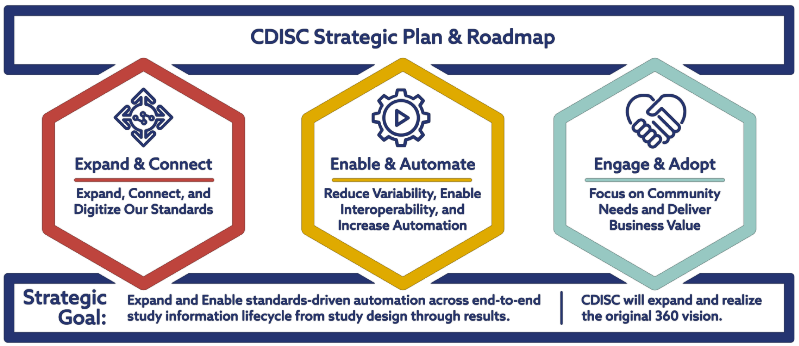

## Abtract

CDISC 360i defines a vision and roadmap to enable standards-driven automation across the clinical research data life cycle - from study design to analysis. The purpose of this paper is to demonstrate the 360i Technical Roadmap by showcasing a strategy for research data pipeline automation using end-to-end, machine-readable standards metadata.

This demonstration will begin by automating study design using concepts and a standardized model to build a digital protocol. Aligned Case Report Forms (CRFs) and SDTM resources will be automatically generated as downstream artifacts using metadata from the digital protocol.




## Operational Data Store (ODS)


This demonstration incorporates the concept of an 'Operational Data Store'.  Data are aggregated and stored centrally to enable data privacy and efficient implementation of operational activities. The ODS acts as a stable foundation for all subsequent data transformation activities.

Raw clinical data can have its source in many different locations and be collected at site, from electronic devices, provisioned electronically by the subjects, sent electronically by central labs, etc.  Data can be transferred in a variety of formats, i.e., FHIR, Dataset-JSON, Dataset-XML, etc.  It is all stored in the ODS.

In practice, an operational data store may consist of a central platform in which collected data extracted from EDC systems and provided by external vendors may be stored and accessed for downstream activities, such as data cleaning and generation of SDTM datasets.

In addition, artifacts such as SDTM datasets may also be stored and accessed to facilitate other downstream activities such ADaM dataset creation. Using an Operational Data Store can centralize the location of all data being used for study assets and allows controlled access, anonymization of subject data and consistent cleaning and transformation of data collected during the study lifecycle.

In this demonstration, the Colab file system serves as the Operational Data Store (ODS).

A mounted Google Drive can also serve as the Object Store or Operational Data Storage (ODS) for our 360i workflow.

Following completion of the notebook, copy all study artifacts to Google Drive to persist in the Operational Data Store.
```
from google.colab import drive
drive.mount('/content/drive')

!ls -l drive/MyDrive/resources/
```

## Building a Digital Protocol with USDM

### Digital Protocol USDM

Traditionally, designing a study requires manual management of study-specific artifacts. A study design is extensively documented by researchers in artifacts such as the Study Protocol and Statistical Analysis Plans (SAP). Artifacts to support downstream activities, such as Case Report Forms (CRF) used for data collection, must be aligned with the study design. Today, study design artifacts may be manually prepared, reviewed by different teams, and finalized in isolation. Disconnected artifacts created and maintained through manual processes can lead to content inconsistencies, compromising data traceability and quality, with increased resources needed for routine activities.

CDISC 360i enables a more streamlined and efficient study design process by leveraging the CDISC Unified Study Definitions Model (USDM), Biomedical Concepts (BC), and Controlled Terminology to enable automation and the use of tools to build efficiencies. The goal is to build direct connections between study design artifacts and promote standardized, shared development and management of artifacts across study teams.   

In 360i, study design is centralized through development and mantenance of a digital study protocol. Content within a protocol is standardized per the CDISC USDM. The USDM provides a framework for the structure of protocol content and allows content to be standardized using BCs and Controlled Terminology. The use of standardized concepts and terminology as part of this framework allows concepts and terminologies to be reused via automation across many artifacts ensuring alignment and enhance data traceability and quality.

Two separate solutions have been used to create the USDM JSON study design used for downstream processing in the 360i initiative:

* Study Definitions Workbench (SDW)
* Open Study Builder (OSB)

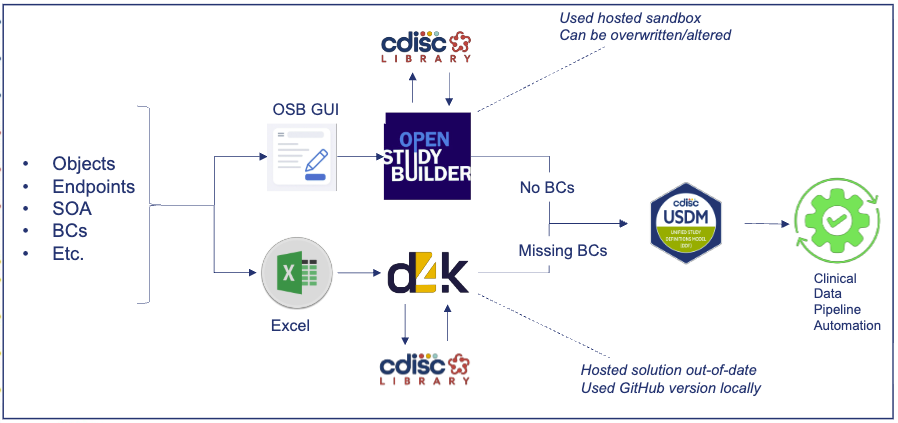

#### Study Definitions Workbench (SDW)

*   Open source project can be cloned from GitHub: https://github.com/data4knowledge/study_definitions_workbench
*   Easy-to-use Excel design template

At the time of writing, the SDW is accessed from the web interface: https://d4k-sdw.fly.dev/

The protocol USDM JSON file defines the Schedule of Activities, associates these activities with Biomedical Concepts and becomes the input for downstream 360i processes.




#### OpenStudyBuilder (OSB)

Similarly, the Open Study Builder is an open source project for the creation of clinical study specifications.

The project aims to deliver end-to-end consistency and more efficient processes from protocol development and CRF design through to the creation of data sets for analysis, reporting and submission.

The OSB includes the web-based interface, the Metadata Repository for all study specification data, and an API layer enabling the integration with other source and target systems.

Additional information on accessing the online environment or hosting an instance locally is available here: https://www.openstudybuilder.com/

The project source code is freely available for download or contribution: https://gitlab.com/Novo-Nordisk/nn-public/openstudybuilder/OpenStudyBuilder-Solution


### USDM JSON

The study design XLSX template has been used in the ***Study Definition Workbench*** to create a version 4 USDM JSON document adhering to the standards defined in the USDM implementation guide.

This digital protocol serves as the input for all downstream processes.

The assets for the example protocol used throughout this notebook are freely available on github: https://github.com/cdisc-org/360i/tree/main/data/protocol/LZZT/usdm


#### Creating and Validating the USDM Study Design

**Configure the environment to be used throughout automation**

This includes the installation of dependencies, setting of variables, definition of functions, etc.

In order to execute this notebook, the user must have access to Google Drive.

In [ ]:
# @title
# Debug statements
!which python
!python --version
!R --version

# Install Dependencies
!pip install -q requests cairosvg validators pathvalidate saxonche click xmlschema dominate
!apt-get install -y libxml2-utils

# Import modules
import os
import urllib
from urllib.parse import urlparse
from google.colab import files, userdata, drive
from IPython.core.display import display, JSON, HTML
import subprocess
import shutil
import json
import pandas as pd
import requests
import io
import pygame
import cairosvg
import PIL.Image
from google.colab import drive

# Define global variables
CONTENT_DIR = '/content/study'
DATA_DIR = os.path.join(CONTENT_DIR, 'data')
CRF_DIR = os.path.join(DATA_DIR, 'crf')
OUTPUT_DIR = os.path.join(CONTENT_DIR, 'output')
PARQUET_DIR = os.path.join(DATA_DIR, 'parquet')
WORKING_DIRS = [DATA_DIR, CRF_DIR, OUTPUT_DIR, PARQUET_DIR]
UTIL_DIRS = []

# Define functions
def change_working_dir(working_dir):
    pwd = os.getcwd()

    if pwd == working_dir:
        print("INFO: Already in the {} project directory...".format(working_dir))
    else:
        print("INFO: Changing to the {} working directory...".format(working_dir))
        try:
            os.chdir(working_dir)
        except FileNotFoundError:
            print("ERROR: {} does not exist...".format(working_dir))

def render_svg(svg_data, scale):
    svg_data = cairosvg.svg2svg(svg_data, dpi=(96 / scale))
    png_data = cairosvg.svg2png(svg_data)
    byte_io = io.BytesIO(png_data)
    return pygame.image.load(byte_io)

def create_dir(target_dir):
    # requires import os
    if os.path.exists(target_dir):
        print("INFO: {} exists...".format(target_dir))
    else:
        print("INFO: Creating directory {}...".format(target_dir))
        os.mkdir(target_dir)

#drive.mount('/content/drive')

In [ ]:
# @title
# Create directories, if required
print("INFO: Creating {}...".format(CONTENT_DIR))
create_dir(CONTENT_DIR)
change_working_dir(CONTENT_DIR)
for dir in WORKING_DIRS:
  print("INFO: Creating {}...".format(dir))
  create_dir(dir)

**Clone validation utility repository**

For the validation of the USDM JSON file to ensure compliance with the USDM v4.0 schema, an open-source utility is cloned and used to validate the structure.

In [ ]:
# @title
# Clone the GitHub repository that contains the validation utility
change_working_dir(CONTENT_DIR)
repo = 'https://github.com/pendingintent/cdisc-json-validation'
!git clone {repo}
project = urlparse(repo)[2]
validation_dir = project[project.rindex('/')+1:len(project)]
UTIL_DIRS.append(validation_dir)
change_working_dir(validation_dir)

This is one of many utilities developed and shared within the open-source community to help facilitate the 360i vision.

The *study* directory now appears as:

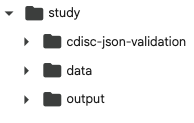

**Upload the Study Design workbook used to define the study and from which the USDM JSON file is created**

Examine the study design workbook to learn about the study Schedule of Activities.

For this step, there is a manual step that needs to take place first. Using the github URL below, download the pilot_LZZT_protocol.xlsx file, as well as the pilot_LZZT_protocol.json file into a local directory. Then when you run the cell below, as it is running, click on 'Choose Files' and select the xlsx version of the protocol to upload.

In [ ]:
# @title
# Upload the file
# 'https://github.com/cdisc-org/360i/raw/main/data/protocol/LZZT/usdm/pilot_LZZT_protocol.xlsx'
change_working_dir(DATA_DIR)
uploaded = files.upload()
xlsx_file_name = list(uploaded)[0]
xlsx_file_path = os.path.join(DATA_DIR, xlsx_file_name)
print(xlsx_file_path)

The Study Design Workbook is an XLSX file defining the study Schedule of Activities as well as other study properties and metadata required in the USDM JSON Study Design.

Once uploaded to the working directory and Operational Data Store, this file can be versioned and serves as the source definition for the study when used in the Study Definition Workbench to create the USDM JSON study definition.

**View the schedule of activities and associcated Biomedical Concepts**

In [ ]:
# @title
# View the mainTimeline worksheet
change_working_dir(os.path.join(DATA_DIR))
results_file = xlsx_file_name
df = pd.read_excel(results_file, sheet_name='mainTimeline')
display(df)

The ***Schedule of Activities*** is defined in the study design template for the LZZT Pilot study. The SoA includes Biomedical Concepts for Procedures used during a subject journey through the study timeline.

In the table above, the study Schedule of Activities is clear and the Biomedical Concepts defining the Procedures scheduled for each activity and across visits can be seen.

**Row 21** displays the Biomedical Concepts for Vital Signs.  These Biomedical Concepts (BCs) will be used to aid in the automation of Case Report Form creation and annotation.

It is from this XLSX document that the USDM JSON file is created using the **Study Defition Workbench**.

**Select the USDM JSON file created using the Study Definitions Workbench**

Once the study has been defined in the Workbook above, it is loaded into the Study Definition Workbench to create the USDM JSON study definition.

The JSON file will be uploaded into the working directory and Operational Data Store.

With this step, run the cell and when it start running, click 'Choose Files' and upload the previously downloaded JSON version of the protocol.

In [ ]:
# @title
# Upload the file
# 'https://github.com/cdisc-org/360i/raw/main/data/protocol/LZZT/usdm/pilot_LZZT_protocol.json'
change_working_dir(DATA_DIR)
uploaded = files.upload()
usdm_file_name = list(uploaded)[0]
usdm_file_path = os.path.join(DATA_DIR, usdm_file_name)
print(usdm_file_path)

Now that the JSON file has been uploaded into the environment, it can be used for further downstream processing.

**View the uploaded JSON file**

In [ ]:
# @title
# View uploaded files
print(usdm_file_path)
with open(usdm_file_path, 'r') as f:
    usdm_data = json.load(f)
display(JSON(usdm_data))



Quick analysis of the JSON file identifies the JSON document as a USDM v4 design document.

"usdmVersion": "4.0.0"

In order ot ensure compliance with the USDM V4.0 standard, the open-source utility cloned earlier can be used.

**Validate the JSON file using the utility**

In a previous step, an open-source USDM validation utility was cloned.  This utility can be used to validate the USDM study definition against the v4.0 JSON schema.

In [ ]:
# @title
# Validate the USDM JSON v4
validation_dir = os.path.join(CONTENT_DIR, 'cdisc-json-validation')
change_working_dir(validation_dir)
result = subprocess.run(["python", "validate.py", usdm_file_path], capture_output=True, text=True)
if "Validation successful" not in result.stdout:
    print("ERROR: Validation of {} not successful...".format(usdm_file_path))
else:
    print("INFO: Validation of {} is successful...".format(usdm_file_path))

The newly uploaded JSON file validates against the version 4.0 USDM JSON schema.

**Validate the JSON file using CDISC Rules Engine**

Although the USDM JSON file validates against the schema, more detailed validation is required.  This is where the CDISC Conformance Rules Engine can validate the USDM JSON stduy definition.

The CDISC Conformance Rules (**CORE**) serve as guidance for the industry on the correct implementation of Standards in Clinical Trials.  These conformance rules can be used throughout the study lifecycle to ensure conformance with the standards ensuring the data is as close to submission-ready as possible.

The CDISC rules engine is an open-source project designed for validating clinical trial data against CDISC Conformance Rules as well as any custom conformance rules defined by the user.

Conformance Rules are under constant development and are all included in the CDISC Library.

Additional information on the Conformance Rules is included later in this notebook

More information is available at: https://www.cdisc.org/core

**Install the CDISC CORE Rules Engine**

A platform-specific release was created for the CORE engine to function in this target environment. The Google Colab environment runs on Ubuntu 22.04.4 LTS. This version uses specific versions of libraries and, therefore, a platform-specific release for the CDISC Rules engine is required.

If a platform-specific release is required to meet dependency or platform requirements, instructions are available in the project: https://github.com/cdisc-org/cdisc-rules-engine/blob/main/README_Build_Executable.md

In [ ]:
# @title
# A specific release has been created for this environment a
change_working_dir(CONTENT_DIR)
core_dir = os.path.join(CONTENT_DIR, 'core')
UTIL_DIRS.append(core_dir)
if os.path.exists(core_dir):
  print("INFO: CDISC Open Rules Engine already exists...")
else:
  src = 'https://github.com/cdisc-org/cdisc-rules-engine/releases/download/v0.13.0/core-ubuntu-22.04.tar.gz'
  zip_file = os.path.basename(urllib.parse.urlsplit(src).path)
  UTIL_DIRS.append(zip_file)
  if os.path.exists(zip_file):
    print("INFO: {} already exists, so no need to download...".format(zip_file))
  else:
    print("INFO: Downloading CORE release...")
    !wget {src}

Directory will now appear as:

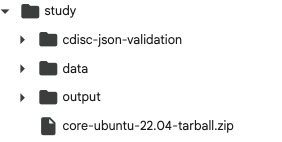

**The CDISC Open Rule Engine will now be extracted and configured for use**

In [ ]:
# @title
# Configure environment for CORE
change_working_dir(CONTENT_DIR)
if os.path.exists(os.path.join(CONTENT_DIR, 'core')):
  print("INFO: CDISC Open Rules Engine already exists...")
else:
  src = 'core-ubuntu-22.04.tar.gz'
  if os.path.exists(src):
    print("INFO: Extracting {} archive....".format(src))
    UTIL_DIRS.append(src)
    if os.path.exists(src):
      print("INFO: Extracting {}...".format(src))
      !tar -zxf {src} > /dev/null 2>&1
      change_working_dir('core')
      !chmod +x ./core
      print("INFO: CORE executable set up successfully.")
  else:
    print("ERROR: {} does not exist...".format(src))

*study* directory will now appear as:

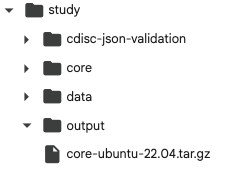

Once extracted, the CORE engine rules local cache can be updated.  In order to update the local CORE engine rules cache, the environmental parameter CDISC_API_KEY must exist.

Use the command `python core.py update-cache --api-key <CDISC_API_KEY>`

**Use the CDISC Rules Engine to validate the USDM JSON file against the Conformance Rules from the CDISC Library**

All of the CDISC Library Conformance Rules for USDM v4.0 will be executed against the USDM JSON study design file.

For additional information on how to execute the CORE validation rules and the options that are available, consult the README: https://github.com/cdisc-org/cdisc-rules-engine

In [ ]:
# @title
# Validate the USDM JSON file against the USDM version 4 Conformance Rules
core_dir = os.path.join(CONTENT_DIR, 'core')
UTIL_DIRS.append(core_dir)
change_working_dir(core_dir)
destination_path = os.path.join(DATA_DIR, 'usdm_validation_results')
!./core validate -s USDM -v 4-0 -o {destination_path} -dp {usdm_file_path}

**View the Rules Report list of USDM core tests executed**

A comprehensive **Conformance Report** is created as an Excel Workbook.

In [ ]:
# @title
# Create a pandas dataframe to view the Rules Report worksheet in the report
# produced by the CORE Engine
results_file = destination_path + '.xlsx'
df = pd.read_excel(results_file, sheet_name='Rules Report')
display(df)

This report worksheet lists all of the conformance rules run to validate the USDM JSON file adn whether the execution was successful.

**View the Issue Sumary produced by the CORE Engine**

The Conformance Report contains details for each of the conformance tests and results.

In [ ]:
# @title
# Create a pandas dataframe to view the Issue Summary worksheet in the report
# produced by the CORE Engine
df = pd.read_excel(results_file, sheet_name='Issue Summary')
display(df)

This report worksheet summarizes any issues identified during validation of hte USDM JSON file.

The report identifies two conformance rules for which issues were identified in the JSON file:

 * CORE-000810
 * CORE-000427

At this point, a USDM JSON file has been created from the study design workbook file using the Study Definition Workbench.

The JSON file format is then validated against the USDM JSON
version 4 schema.

The CORE Engine is then used to execute the USDM v4.0 Conformance Rules from the CDISC Library against the USDM JSON file .



---



### OpenStudyBuilder (OSB)



***In order to execute the Open Study Builder API demonstration cells below, the session must use a valid Bearer Token.  If the user executing this notebook does not have access to the OSB environment or does not know how to include a valid Bearer Token in this session, skip this section.***

**Set bearer token**

The Open Study Builder requires authorization. Using OAuth2 requires manual intervention in the browser to retrieve the CODE value generated for authorization.

Similarly, the bearer token can be retrieved from the request header using the browser Developer Tools from an authorized Open Study Builder session.

The bearer token has a relatively short TTL and will need to be updated (at least) once a session.

Add an OSB_BEARER_TOKEN environmental variable using the secrets menu image.png

In [ ]:
# @title
# The bearer token can be entered as an environmental variable or stored in the Colab secrets
# bearer_token = ''
bearer_token = userdata.get('OSB_BEARER_TOKEN')

**Retrieve the study USDM JSON file from the OSB API**

The JSON text can be stored in a variable or written to a file and added to object storage.

In [ ]:
# @title
# Get USDM JSON from OSB study
# Hard-coded URL for the OpenStudyBuilder Sandbox instance.
study_uid = 'Study_000016'
url = 'https://openstudybuilder.northeurope.cloudapp.azure.com/api/usdm/v3/studyDefinitions/' + study_uid
headers = {
    'Authorization': 'Bearer ' + bearer_token,
    'Content-Type': 'application/json'
}

try:
  response = requests.get(url, headers=headers)
  response.raise_for_status()
  data = response.json()
  display(JSON(data))
except requests.exceptions.RequestException as e:
  print("Error: {}".format(e))
  print("Status Code: {}".format(response.status_code if response else "N/A"))
  print("Response Body: {}".format(response.text if response else "N/A"))


The USDM JSON document for a study defined in the OSB can be accessed through the API for validation and use in downstream automation.

**Use the API to get study properties**

In [ ]:
# @title
# Get basic study properties

headers = {
    'Authorization': f'Bearer {bearer_token}',
    'Content-Type': 'application/json'
}

url = 'https://openstudybuilder.northeurope.cloudapp.azure.com/api/studies/Study_000016?ignoreErrors=true&study_value_version=4'

try:
  response = requests.get(url, headers=headers)
  json_data = response.json()
  print('Study Name: {}'.format(json_data['current_metadata']['identification_metadata']['study_id']))
  print('Study UID: {}'.format(json_data['uid']))
  print('Description: {}'.format(json_data['current_metadata']['study_description']['study_title']))
  print('Version: {}'.format(json_data['current_metadata']['version_metadata']['version_number']))
  print('Author: {}'.format(json_data['current_metadata']['version_metadata']['version_author']))
except requests.exceptions.RequestException as e:
  print("Error: {}".format(e))
  print("Status Code: {}".format(response.status_code if response else "N/A"))
  print("Response Body: {}".format(response.text if response else "N/A"))


**Get the Study Schema**

The purpose of the Study Schema is to provide a visual depiction of the trial design, orienting users of the protocol to the key features of the design. The schema displays the trial arms, the flow of individual participants through the progression of trial period(s)/epochs (such as screening, washout/run-in, intervention, and key milestones [for example, randomization, cross-over, end of treatment]).

In [ ]:
# @title
# Use the API to return the study schema from OSB
headers = {'Authorization': f'Bearer {bearer_token}'}
url = 'https://openstudybuilder.northeurope.cloudapp.azure.com/api/studies/Study_000016/design.svg?study_value_version=4'

try:
  response = requests.get(url, headers=headers)
  print(response.status_code)

  # Check if the response is an SVG image
  if 'image/svg+xml' in response.headers.get('Content-Type', ''):
      svg_content = response.text
      image = render_svg(svg_content, 1)

      pil_image = PIL.Image.frombytes("RGBA", image.get_size(), image.get_buffer().raw)

      display(pil_image)
  else:
      print("The response is not an SVG image.")
      print(response.text)
except requests.exceptions.RequestException as e:
  print("Error: {}".format(e))
  print("Status Code: {}".format(response.status_code if response else "N/A"))
  print("Response Body: {}".format(response.text if response else "N/A"))


**Display the Protocol Operational SoA**

The Schedule of Activities can be retrieved through the OSB APIs.

In [ ]:
# @title
# Use the api to return the Schedule of Activities from OSB
headers = {'Authorization': f'Bearer {bearer_token}'}
url = 'https://openstudybuilder.northeurope.cloudapp.azure.com/api/studies/Study_000016/flowchart.html?layout=protocol&study_value_version=4'

try:
  response = requests.get(url, headers=headers)
  print(response.status_code)
  display(HTML(response.text))
except requests.exceptions.RequestException as e:
  print("Error: {}".format(e))
  print("Status Code: {}".format(response.status_code if response else "N/A"))
  print("Response Body: {}".format(response.text if response else "N/A"))


**Display the ICH M11 Template for the study**

The alignment of the USDM standard with the ICM M11 CeShaRP supports the automated propulation of the M11 Template with objects defined in the USDM resulting in the creation of a digital protocol document.

In [ ]:
# @title
# Use the api to return the populated ICM M11 template
headers = {'Authorization': f'Bearer {bearer_token}'}
url = "https://openstudybuilder.northeurope.cloudapp.azure.com/api/usdm/v3/studyDefinitions/Study_000016/m11"

try:
  response = requests.get(url, headers=headers)
  print(response.status_code)
  display(HTML(response.text))
except requests.exceptions.RequestException as e:
  print("Error: {}".format(e))
  print("Status Code: {}".format(response.status_code if response else "N/A"))
  print("Response Body: {}".format(response.text if response else "N/A"))


Scroll to Section 1.3 to view the Schedule of Activities for the Study.  

**The OSB offers a comprehensive collection of APIs that enable discovery of study design objects.**

For more information on available OSB APIs, please refer to https://openstudybuilder.northeurope.cloudapp.azure.com/api/docs



---



## Case Report Forms and Form Annotation

### Electronic Case Report Forms

CDISC 360i uses study design elements maintained in the digital protocol with standard metadata to automate the design of electronic case report forms (eCRFs) data collection artifacts. Automation significantly reduces the time and effort required for CRF development and configuration and improves the quality and consistency of eCRFs by minimizing manual design and configuration errors. It ensures better adherence to CDISC standards and facilitates faster data collection setup.





### Annotated Case Report Forms (aCRF)

Automating the creation of aCRF from the study design phase drastically reduces the time taken to manually annotate the CRFs.  These annotated CRFs serve as the input from which the CRF designs are generated.

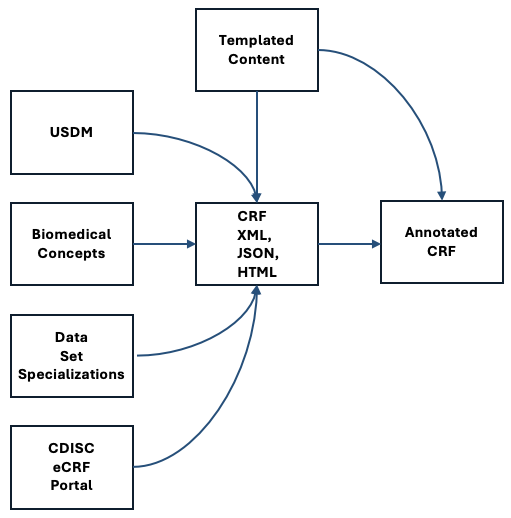

**Clone the repository containing the required utilities**

An open-source solution has been developed to facilitate the automated creation and annotation of the Case Report Forms in easy to display HTML as well as ODM XML and JSON dataset transformation compliant formats.

Clone the GitHub repository: https://github.com/lexjansen/cdisc360i-pocs.git


In [ ]:
# @title
# Clone the GitHub repository that contains the validation utility
change_working_dir(CONTENT_DIR)
repo = 'https://github.com/lexjansen/cdisc360i-pocs'
!git clone {repo}
project = urlparse(repo)[2]
working_dir = os.path.join(CONTENT_DIR, project[project.rindex('/')+1:len(project)])
UTIL_DIRS.append(working_dir)
change_working_dir(working_dir)
# Include the uninstall of ODMLIB to ensure there are no conflicting libraries
!pip uninstall -y odmlib

*study* directory now appears as:

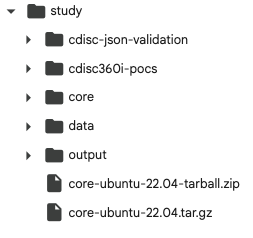

**Generate the anotated Case Report Forms and the Case Report Forms for data entry**

Execution of the utility will create an HTML version of the CRF, an HTML version of the annotated CRF, a JSON representation and an XML representation of the CRF.


In [ ]:
# Generate ODM XML v2.0 XML, CRFs in HTML, and annotated HTML CRFs for Vital Signs
%%python ./bc_dss2crf/cdash_poc_odm20.py -f VS1 -p vital_signs

In [ ]:
# @title
# Move and rename CRF files
for file in os.listdir('crf/VS1'):
  print("INFO: Copying {} to {}...".format(file, CRF_DIR))
  shutil.copy2(os.path.join('crf/VS1', file), CRF_DIR)

In [ ]:
# Generate ODM XML v2.0 XML, CRFs in HTML, and annotated HTML CRFs for Demography
%%python ./bc_dss2crf/cdash_poc_odm20.py -f DEMOG_LZZT -p demographics

In [ ]:
# @title
# Move and rename CRF files
for file in os.listdir('crf/DEMOG_LZZT'):
  print("INFO: Copying {} to {}...".format(file, CRF_DIR))
  shutil.copy2(os.path.join('crf/DEMOG_LZZT', file), CRF_DIR)

**Display the files created**

View the CRF files that are produced.

In [ ]:
# View the Vital Signs CRF
display(HTML(os.path.join(CRF_DIR, 'vital_signs_odmv2-0_crf.html')))

In [ ]:
# View the Vital Signs Annotated CRF
display(HTML(os.path.join(CRF_DIR, 'vital_signs_odmv2-0_acrf.html')))

ODM XML files are also created along with the HTML assets for integration with compliant Electronic Data Capture systems.

In [ ]:
# @title
# View the ODM-XML for the Vital Signs form
file = os.path.join(CRF_DIR, 'vital_signs_odmv2-0.xml')
print(file)
!xmllint --format {file} -o {file}
!cat {file}

The Diastolic Blood Pressure shown in the annotated CRF above identifies the biomedical concept code as **C25299**.

In the ODM-XML, the \<ItemGroupDef> identifier "IG.VS_02_2_DIABP_HORIZONTAL_7" corresponds to the item group shown in the annotated CRF.  The items belonging to the ItemGroup are referenced with \<ItemRef> in order as shown on the CRF with the corresponding coding system values.
```
<ItemGroupDef OID="IG.VS_02_2_DIABP_HORIZONTAL_7" Name="Diastolic Blood Pressure (Horizontal)" Repeating="No" Type="Concept">
        <Description>
          <TranslatedText Type="text/plain" xml:lang="en">Diastolic Blood Pressure (Horizontal)</TranslatedText>
        </Description>
        <ItemRef ItemOID="IT.VS_02_2_DIABP_HORIZONTAL_7.VSDAT" OrderNumber="1" Mandatory="No"/>
        <ItemRef ItemOID="IT.VS_02_2_DIABP_HORIZONTAL_7.DIABP_VSPOS" OrderNumber="2" Mandatory="No"/>
        <ItemRef ItemOID="IT.VS_02_2_DIABP_HORIZONTAL_7.DIABP_VSLOC" OrderNumber="3" Mandatory="No"/>
        <ItemRef ItemOID="IT.VS_02_2_DIABP_HORIZONTAL_7.DIABP" OrderNumber="4" Mandatory="Yes"/>
        <ItemRef ItemOID="IT.VS_02_2_DIABP_HORIZONTAL_7.DIABPU" OrderNumber="5" Mandatory="Yes" PreSpecifiedValue="mmHg"/>
        <Coding System="/mdr/bc/biomedicalconcepts/C25299" Code="C25299" SystemName="CDISC Biomedical Concept"/>
        <Coding System="/mdr/specializations/sdtm/datasetspecializations/DIABP" Code="DIABP" SystemName="CDISC SDTM Dataset Specialization"/>
</ItemGroupDef>
```
When viewing the ItemDef for each item, the corresponding \<CodeListRef> for the SDTM Data Set Specialization (DSS) is shown.

```
<ItemDef OID="IT.VS_02_2_DIABP_HORIZONTAL_7.DIABP_VSPOS" Name="DIABP_VSPOS" DataType="text" Length="50">
  <Prompt>
    <TranslatedText Type="text/plain" xml:lang="en">Position</TranslatedText>
  </Prompt>
  <CodeListRef CodeListOID="CL.VS_02_DIABP_HORIZONTAL_7.DIABP_VSPOS.C71148"/>
  <Alias Context="SDTM" Name="VSPOS when VSTESTCD = DIABP"/>
</ItemDef>
```
Examining the XML further reveals the drop-down selection options available for subject postition while taking Diastolic Blood Pressure during the procedure.
```
<CodeList OID="CL.VS_02_DIABP_HORIZONTAL_7.DIABP_VSPOS.C71148" Name="POSITION" DataType="text">
  <CodeListItem CodedValue="PRONE">
    <Decode>
      <TranslatedText Type="text/plain" xml:lang="en">Prone</TranslatedText>
    </Decode>
  </CodeListItem>
  <CodeListItem CodedValue="SEMI-RECUMBENT">
    <Decode>
      <TranslatedText Type="text/plain" xml:lang="en">Semi-recumbent</TranslatedText>
    </Decode>
  </CodeListItem>
  <CodeListItem CodedValue="SITTING">
    <Decode>
      <TranslatedText Type="text/plain" xml:lang="en">Sitting</TranslatedText>
    </Decode>
  </CodeListItem>
  <CodeListItem CodedValue="STANDING">
    <Decode>
      <TranslatedText Type="text/plain" xml:lang="en">Standing</TranslatedText>
    </Decode>
  </CodeListItem>
  <CodeListItem CodedValue="SUPINE">
    <Decode>
      <TranslatedText Type="text/plain" xml:lang="en">Supine</TranslatedText>
    </Decode>
  </CodeListItem>
  <Coding System="https://www.cdisc.org/standards/terminology" Code="C71148" SystemName="CDISC/NCI CT"/>
</CodeList>
```

The HTML, JSON and XML files are used to generate the Case Report Forms used in the study.  The annotated CRF files are used in the SDTM submission for the study.

## SDTM Resources

### SDTM Define-xml

The SDTM Define-xml is a critical component for regulatory submissions and provides metadata for submitted datasets. CDISC 360i automates the generation of the Define-xml using the study-specfic metadata created as part of the digital protocol and downstream eCRFs and eDTs.

Automating Define-xml generation reduces manual effort and saves time and resources. The SDTM Define-xml can be used to automate SDTM shell datasets.

### SDTM Shell Datasets

SDTM shell datasets, whether they are SAS, CSV, database schema scripts, define the SDTM variables and their attributes, but contain no rows of data.

Validating the data sets adhere to the complex SDTM mapping rules represents a challenge.  Complex inter-dataset relationships and validation rules present a challenge to the study team.  

The 360i approach addresses this by emphasizing the quality and standardization of hte SDTM specifications used as input.  Automated validation checks can be performed on the generated shell datasets to verify variable attributes against the specifications and CDISC rules. Integration with downstream data loading and processing steps (like ODS) helps identify any structural incompatibilities early in the process.

Automating shell dataset generation significantly reduces manual programming effort and improves the accuracy and consistency of the dataset structures by eliminating manual coding errors.

### SDTM Trial Design Domains

The Trial Design Domains provide a standardized way in which to clearly and briefly describe the overall plan and design of a study.

The domains contain data set describing the trial arms, trial elements, trial visits, trial inclusion/exclusion criteria and trial summary facts.

It is beneficial to have these domains early in the trial design lifecycle.  Fortunately, the data needed to create these domains is avialable in the USDM JSON file.

### 360i Approach

The 360i project aims to streamline and automate the creation of the Define-XML document leveraging the Unified Study Definition Model (USDM), Biomedical Concepts (BC) and Data Set Standards (DSS).



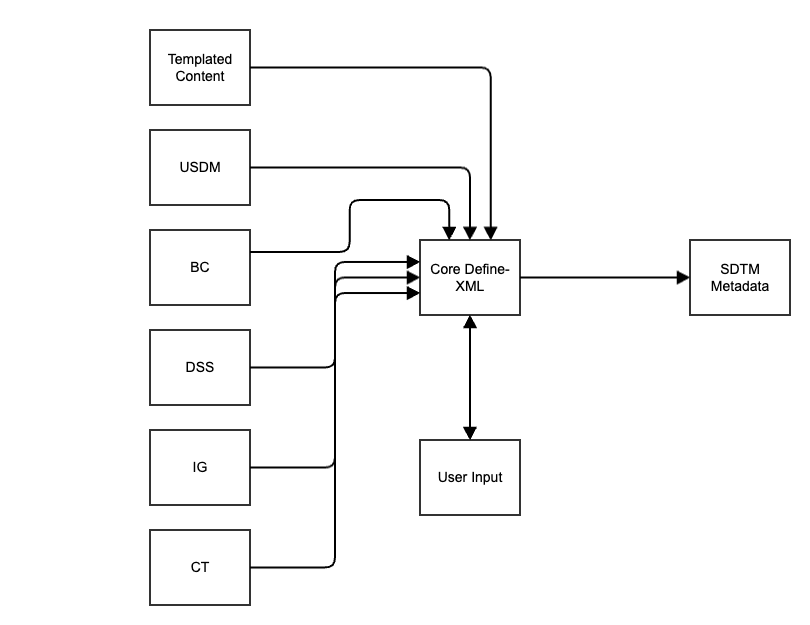

**Clone the Github respoitory containing the USDM utilities**

The cdisc-usdm-utils project includes utilities to generate SDTM domain outputs (CSV + Dataset-JSON v1.1), and XPT files from USDM.  Like all other repositories used in the notebooks, this project is public and distributed under the MIT license.  Feel free to clone and fork the repository as well as raise Issues, feature requests and Pull requests for tested changes.

In [ ]:
# @title
# Clone the utilities
change_working_dir(CONTENT_DIR)
repo = 'https://github.com/pendingintent/cdisc-usdm-utils'
branch = 'dataset-xpt'
!git clone -b {branch} {repo}
project = urlparse(repo)[2]
utils_dir = project[project.rindex('/')+1:len(project)]
UTIL_DIRS.append(utils_dir)
change_working_dir(utils_dir)

*study* directory now appears as:

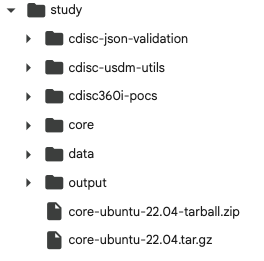

### Create the Trial Design Datasets

**Create TA, TE, TV, TI and TS Trial Design Domains**

The cdisc-usdm-utils and the uploaded USDM JSON file are used to create the Trial Design Domains using specifications included in the utilities.  This is another example of open-source utilties created in collaboration with the CDISC 360i team.

In [ ]:
# @title
# execute the utility to create the trial design domains TA, TV, TE, TI, TS
change_working_dir(os.path.join(CONTENT_DIR, utils_dir))
# Install the package in editable mode
!pip install -e .
#create_dir(OUTPUT_DIR)
usdm_file_path = os.path.join(DATA_DIR, usdm_file_name)
print(usdm_file_path)
print(OUTPUT_DIR)
!python -m cdisc_usdm_utils.cli sdtm all --usdm-file {usdm_file_path} --out-dir {OUTPUT_DIR}

**Generate the Trial Design Domain XPT files for CORE validation**

The notebook installation of our CDISC Conformance Rules Engine executes against XPT format dataset files.

The cdisc-usdm-utils is used to produce submission-ready SAS XPT files.

In [ ]:
# @title
# Ensure the xpt directory exists and generate the XPT files
!pip install pyreadstat
xpt_dir = os.path.join(OUTPUT_DIR, 'xpt')
csv_dir = OUTPUT_DIR
create_dir(xpt_dir)
!python -m cdisc_usdm_utils.cli xpt --csv-dir {csv_dir} --out-dir {xpt_dir}

**View the contents of the TA domain**

(Optional) View the contents of the TA domain to ensure it meets expectations.

In [ ]:
# @title
# Display TA domain as DataFrame
df = pd.read_csv(os.path.join(OUTPUT_DIR, "TA.csv"))
display(df)

**View the contents of the TE domain**

(Optional) View the contents of the TE domain to ensure it meets expectations.

In [ ]:
# @title
# Display TE domain as DataFrame
df = pd.read_csv(os.path.join(OUTPUT_DIR, "TE.csv"))
display(df)

**View the contents of the TV domain**

(Optional) View the contents of the TV domain to ensure it meets expectations.

In [ ]:
# @title
# Display TV domain as DataFrame
df = pd.read_csv(os.path.join(OUTPUT_DIR, "TV.csv"))
display(df)

**Validate conformance using the CORE engine**

As seen in the Study Design notebook demonstration, the CDISC CORE Engine can be used to run Conformance Rules from the CDISC Library to validate the SDTM Trial Design Domains.  A validation report is created for any validation executed by the CORE Engine.

In [ ]:
# @title
# execute SDTM validation
change_working_dir(core_dir)
destination_path = os.path.join(DATA_DIR, 'sdtm_validation_results')
!./core validate -s SDTMIG -v 3-4 -o {destination_path} -d {xpt_dir}

**View the Rules Report list of USDM core tests executed**

View the Summary Rules Report from the CORE Report XLSX file.

Do not show the SKIPPED rules.

In [ ]:
# @title
# Create a pandas dataframe to view the Rules Report worksheet in the report
# produced by the CORE Engine
results_file = destination_path + '.xlsx'
df = pd.read_excel(results_file, sheet_name='Rules Report')
df = df[(df['Status']=='SUCCESS')]
display(df)

**View the Issue Sumary produced by the CORE Engine**

View the Issue Summary from the Core Report XLSX file.

In [ ]:
# @title
# Create a pandas dataframe to view the Issue Summary worksheet in the report
# produced by the CORE Engine
df = pd.read_excel(results_file, sheet_name='Issue Summary')
display(df)

The SDTM Trial Design Domain files for the domains TA, TE, TV, TI and TS were created using the tools in the cdisc-usdm-utils library in CSV, JSON and XPT formats.

The CORE Engine was used to execute the SDTMIG v3-4 Conformance Rules from the CDISC Library against the XPT version of the SDTM Trial Design Domain files.

Finally, we viewed the Rules Report and Issue Summary produced by the CORE execution.

**Oragnize contents in the *output* directory**

In [ ]:
# @title
# Copy files to Object Storage or Study Operational Data Store
dest_json = os.path.join(OUTPUT_DIR, 'json')
dest_csv = os.path.join(OUTPUT_DIR, 'csv')
destlist = [dest_json, dest_csv]

for dest in destlist:
  create_dir(dest)

for file in os.listdir(OUTPUT_DIR):
  if file.endswith(".csv"):
    print("INFO: Moving {} to {}...".format(file, dest_csv))
    shutil.move(os.path.join(OUTPUT_DIR, file), os.path.join(dest_csv, file))
  elif file.endswith(".json"):
    print("INFO: Moving {} to {}...".format(file, dest_json))
    shutil.move(os.path.join(OUTPUT_DIR, file), os.path.join(dest_json, file.replace(".dataset", "")))

### Create Define-XML

The Define-Template utility is an open-source solution designed to create the template file used in the creation of the Define-XML file from the study definition in the USDM JSON file.

In [ ]:
# @title
# Clone the GitHub repository that contains the Define-Template utility
change_working_dir(CONTENT_DIR)
repo = 'https://github.com/pendingintent/360i'
branch = 'parse-args'
!git clone -b {branch} {repo}
project = urlparse(repo)[2]
template_util_dir = project[project.rindex('/')+1:len(project)]
UTIL_DIRS.append(template_util_dir)
change_working_dir(template_util_dir)

*study* now appears as:

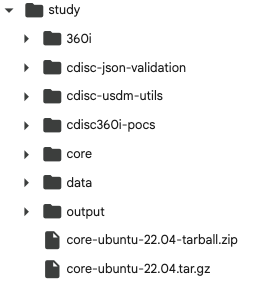

**Execute the code to create the Define-Template file**

Creation of the template takes approximately 8 minutes.  For the purposes of this demonstration, the Define Template will be downloaded from the GitHub repository.

In order to execute the utility to create the Define Template, execute the following command:
```
!python Define-Template.py --usdm_file {usdm_file_path} --output_template {output_template_file} --cdisc_api_key {cdisc_api_key}
```

**Download the Define-Template.json file**

In [ ]:
# @title
# Download resources
url = 'https://github.com/cdisc-org/cdisc-360i-notebooks/raw/main/Define-Template.json'
template_file = os.path.basename(urllib.parse.urlsplit(url).path)
UTIL_DIRS.append(template_file)
change_working_dir(CONTENT_DIR)
if os.path.exists(template_file):
  print("INFO: {} already exists. Skipping download...".format(template_file))
else:
  print("INFO: Donwloading {}...".format(template_file))
  !wget {url}

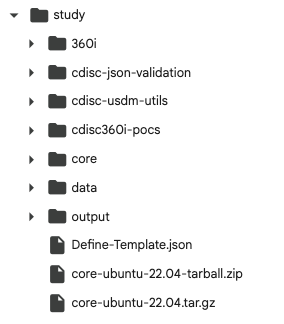

**View the Define-Template.json file**

In [ ]:
# @title
# Display the generated Define Template
display(JSON(template_file))

**Clone the repository for creating the Define-XML file**

The Define Template is used by this open-source solution to generate the Define XML.

In [ ]:
# @title
# Clone the utility for generating the Define-XML
change_working_dir(CONTENT_DIR)
!pip install odmlib
repo = 'https://github.com/swhume/template2define'
!git clone {repo}
project = urlparse(repo)[2]
define_util_dir = project[project.rindex('/')+1:len(project)]
UTIL_DIRS.append(define_util_dir)
change_working_dir(define_util_dir)

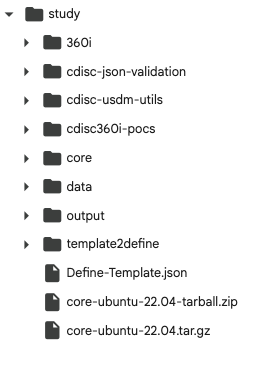

**Execute the utility to generate the Define-XML**

In [ ]:
# @title
# Generate the Define-XML
template_file = os.path.join(CONTENT_DIR, template_file)
define_file = os.path.join(OUTPUT_DIR, 'define.xml')
!python template2define2-1.py -t {template_file} -d {define_file}

**Display the define.xml file**

In [ ]:
# @title
# Format using xmllint for easier viewing
!xmllint --format {define_file} -o {define_file}
!head -100 {define_file}

### Create the Required SDTM Shell Dataset JSON files from the define.xml

Variables required by the SDTM datasets can be determined from the study definition.  Therefore, dataset definitions describing these variables can be created at this stage.

In [ ]:
# @title
# Create the empty shell dataset JSON files
change_working_dir(os.path.join(CONTENT_DIR, template_util_dir))
define_file = os.path.join(OUTPUT_DIR, 'define.xml')
dataset_dir = os.path.join(OUTPUT_DIR, 'shell_datasets')
create_dir(dataset_dir)
#print(dataset_dir)
!python dataset-json.py --define_file {define_file} --output_dir {dataset_dir}

**Display a JSON shell dataset for demonstration**

In [ ]:
# @title
# Display the VS JSON empty shell dataset
display(JSON(os.path.join(dataset_dir, 'VS.json')))

Creation of the Trial Design Datasets, Define-XML and SDTM Domain dataset definition study artifacts can be automated using open-source solutions currently available and created in collaboration with teams at CDISC.



---



## Data Collection and the Operational Data Store

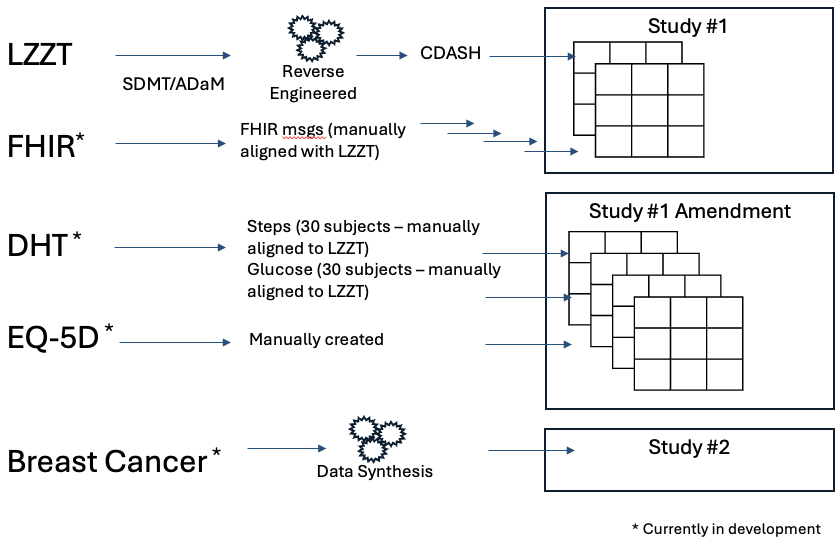

As mentioned at the beginning of this demostration, the Operational Data Store serves as a repository for all study data and improves data governance and traceability for all study teams.

The Google Drive serves as the Object Store for the Operational Data Store.  All assets created to this point now exist in the object store.

Once the study has gone live and subject data is being entered at the sites, this raw, collectd data is stored in a database.  The data loaded into the data is made available to study teams for further downsteam processing, such as the creation of the SDTM data sets.

**Create an Operational Data Store database for use in the demonstration**

Typically a database will exist for the storage of all study data.  For this demonstration, an SQLite database will be created and study data stored in the database.

In [ ]:
# @title
# Create an ODS
import sqlite3
change_working_dir(DATA_DIR)
ods_db = 'ods.db'
conn = sqlite3.connect(os.path.join(DATA_DIR, ods_db))
conn.close()

**Download raw subject data**

Often raw data sets will be stored in object storage and made available to teams for downstream processing.

To emulate this environment, download raw data files from Github.

Raw data sets are available: https://github.com/alidootson/UpdatedCDISCPilotData/tree/main/UpdatedCDISCPilotData/CDASH

The directories include XPT, JSON and CSV format files.

Data is transferred in the open Parquet file format, which provides efficient data compression and encoding schemes with enhanced performance to handle complex data in bulk.


In [ ]:
# @title
# Download CSV files from repo and write out to parquet files to
# store in DATA_DIR
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
change_working_dir(PARQUET_DIR)

domains = ['AE','CM','DM','DS','EX','IE','LB','MH','QS','SC','VS','X1']
repo = 'https://raw.githubusercontent.com/alidootson/UpdatedCDISCPilotData/refs/heads/main/UpdatedCDISCPilotData/CDASH/csv%20versions'

for domain in domains:
  if domain + '.csv' in os.listdir():
    continue
  else:
    file_path = repo + '/' + domain + '.csv'
    df = pd.read_csv(file_path)
    table = pa.Table.from_pandas(df)
    pq.write_table(table, domain + '.parquet')

**Read AE parquet domain file**

Parquet files are a non-human-readable format. Convert into a Pandas dataframe for viewing.

In [ ]:
# @title
# Verify the contents of AE
pd.read_parquet(os.path.join(PARQUET_DIR, 'AE.parquet'), engine='pyarrow')

Parquet files can then be used to create dataframes for cleaning and transformation.

**Read VS parquet domain file**

In [ ]:
# @title
# Verify the contents of VS
pd.read_parquet(os.path.join(PARQUET_DIR, 'VS.parquet'), engine='pyarrow')

**Insert the collected data in the Operational Data Store**

In [ ]:
# @title
# Create tables in the ODS for each of the stored parquet files
# containing subject data
data_files = []
for file in os.listdir(PARQUET_DIR):
  if file.endswith(".parquet"):
    data_files.append(file)

try:
  with sqlite3.connect(os.path.join(DATA_DIR, ods_db)) as conn:
    for file in data_files:
      table = pq.read_table(os.path.join(PARQUET_DIR, file))
      print("INFO: Creating table for {}".format(file))
      df = table.to_pandas()
      df.to_sql('raw_' + file.split('.')[0], conn, if_exists='replace', index = False)
except sqlite3.OperationalError as e:
  print("ERROR: Failed to open database: {}".format(e))
finally:
  print("INFO: Closing database connection...")
  conn.close()

**Confirm a table is created for each of the data sets**

The tables include the prefix '_raw' to differentiate them from processed data sets, i.e., SDMTM, ADaM, etc.

In [ ]:
# @title
# Confirm sqlite tables are created for the parquet files
conn = sqlite3.connect(os.path.join(DATA_DIR, ods_db))
cur = conn.cursor()
cur.execute("SELECT name FROM sqlite_schema WHERE type=='table' AND name NOT LIKE 'sqlite_%';")
print(cur.fetchall())
conn.close()

**Verify record and column counts are equivalent for parquet files and ODS tables**

Use the python `assert` statement to test both column and row counts are equal for the Parquet files and the database tables created for each Parquet file.

In [ ]:
# @title
# Assert all parquet files have same record count as correponding data table
try:
  with sqlite3.connect(os.path.join(DATA_DIR, ods_db)) as conn:
    for file in data_files:
      domain = 'raw_' + file.split('.')[0]
      #print("Testing: {}".format(domain))
      cur = conn.cursor()
      cur.execute("SELECT COUNT(*) FROM {}".format(domain))
      assert cur.fetchone()[0] == pq.ParquetFile(os.path.join(PARQUET_DIR, file)).metadata.num_rows
      print("{} domain passed validation".format(domain))

except sqlite3.OperationalError as e:
  print("ERROR: Failed to open database: {}".format(e))
except AssertionError as e:
  print("ERROR: Record count mismatch")
finally:
  print("INFO: Closing database connection...")
  conn.close()

**Display records in the raw vital signs table to confirm data has been inserted**

SQL SELECT to preview records in the raw_VS table.

In [ ]:
# @title
# Read data from VS table in ODS
conn = sqlite3.connect(os.path.join(DATA_DIR, ods_db))
cur = conn.cursor()
cur.execute("SELECT * FROM raw_VS")
rows = cur.fetchmany(10)
for row in rows:
    print(row)
conn.close()

Clinical data and study assets come from various sources and disparate systems and need to be gathered in a central location.  An Operational Data Store represents a single location comprised of object storage and database(s) where all study objects can be stored to support downstream study requirements.

In this example, a Relational Database is used to store tabular subject data collected during study conduct, which can then serve as the source for downstream transformations into SDTM submission datasets.



---



## SDTM Tabulation Dataset Generation

### The creation of SDTM Datasets in R with \{sdtm.oak}

One of the objectives of CDISC 360i is the automated generation of SDTM submission datasets leveraging Unified Study Definition Model (USDM), Biomedical Concepts (BC) and Data Set Specializations (DSS) terminologies combined with collected raw study data.  

The \{sdtm.oak} project is an Electronic Data Capture (EDC) and Data Standards agnostic solution that enables the pharmaceutical programming community to develop CDISC SDTM datasets using the R language.  This project provides a framework for modular programming leveraging reusable algorithms to achieve automation.


This approach improves data quality and consistency by applying standardized, validated algorithms derived directly from specifications, minimizing human coding errors leading to reduced timelines for analysis and reporting.



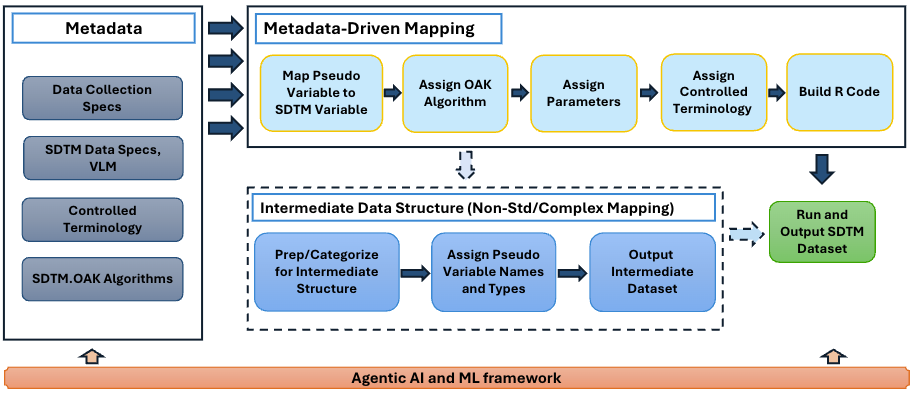

In order to use R code in this Python Notebook, load the required extensions.

In [ ]:
# Setup the R environment within the Python Notebook
%load_ext rpy2.ipython

**Copy the required artifacts from the cloned GitHub repository into the 'study' directory.**

The required artifacts include:

* input_files.zip

In [ ]:
# @title
# Download the required archive from GitHub
change_working_dir(CONTENT_DIR)
input_dir = os.path.join(CONTENT_DIR, 'input_files')
create_dir(input_dir)
UTIL_DIRS.append(input_dir)
change_working_dir(input_dir)

files = ['VS.csv', 'cdisc_collection_dataset_specializations_draft.xlsx',
         'packages.txt', 'study_ct.csv']
prefix = 'https://github.com/cdisc-org/cdisc-360i-notebooks/raw/main/input_files/'

for file in files:
  url = prefix + file
  print("INFO: Downloading {}...".format(url))
  !wget {url}


The *study* directory will now appear as:

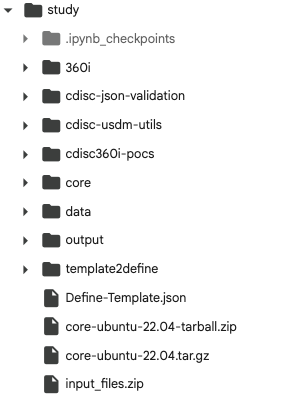

Configure the artifacts for using with **R**.

In [ ]:
# Configure R artifacts
change_working_dir(CONTENT_DIR)
if os.path.exists(input_zip):
  !unzip {input_zip}
  UTIL_DIRS.append('input_files')

Confirm the artifacts for dynamically generating the domain creation script are present and can be accessed using **R**.

In [ ]:
# @title
# Change to working directory and verify resources are accessible
%%R
setwd("input_files")
getwd()
list.files()

The **%%R** magic statement is used to indicate the cell should be executed using the R interpreter.

**Confirm the environment is configured for R correctly**


Load any required **R** libraries.

In [ ]:
# @title
%%R
# Path to your env file
env_file <- "packages.txt"   # change if needed

# Read all package names
pkgs <- scan(env_file, what = "", sep = "\n")

# Find which are missing
to_install <- setdiff(pkgs, rownames(installed.packages()))

# Install only missing ones
if (length(to_install) > 0) {
  install.packages(to_install)
} else {
  message("✅ All packages already installed")
}

**Dynamically Generate the R script to create the VS Findings SDTM Domain**

In [ ]:
# @title

# ==============================================================================
# CDISC SDTM Findings Domain Code Generator
# ==============================================================================
#
# File: emit_findings_oak_from_spec.R
# Purpose: Dynamically generate R code for mapping CDASH raw data to SDTM
#          Findings domains using sdtm.oak package
#
# Input:
#   - CDISC Collection Specializations Excel file
#   - Raw CDASH CSV data file
#   - Study controlled terminology CSV file
#
# Output:
#   - R script for SDTM Findings domain mapping
#   - Generated SDTM dataset CSV file
#
# Author: Auto-generated by CDISC 360I SDTM Oak Code Generator
# Version: 1.0
# Date: $(date)
#
# Dependencies: sdtm.oak, dplyr, readxl
# ==============================================================================
%%R
# Load required packages with error handling
tryCatch({
  if (!requireNamespace("readxl", quietly = TRUE)) {
    stop("Required package 'readxl' is not installed. Please run: install.packages('readxl')")
  }
  if (!requireNamespace("dplyr", quietly = TRUE)) {
    stop("Required package 'dplyr' is not installed. Please run: install.packages('dplyr')")
  }
}, error = function(e) {
  cat("ERROR: Package dependency check failed\n")
  cat("Details:", e$message, "\n")
  stop(e)
})

#' Generate SDTM Findings Domain Mapping Code
#'
#' @description
#' Dynamically generates R code for mapping CDASH raw data to SDTM Findings domains
#' using the sdtm.oak package. The function reads CDISC Collection Specializations,
#' raw data structure, and controlled terminology to produce optimized mapping code.
#'
#' @param spec_path Character. Path to CDISC Collection Specializations Excel file
#' @param raw_csv_path Character. Path to raw CDASH CSV data file
#' @param ct_csv_path Character. Path to study controlled terminology CSV file
#' @param domain Character. Target SDTM domain code (default: "VS")
#' @param out_r_path Character. Output path for generated R script (optional)
#'
#' @return Character vector containing the generated R code lines
#'
#' @examples
#' \dontrun{
#' # Generate VS domain mapping code
#' code_lines <- emit_findings_oak_from_spec(
#'   spec_path = "cdisc_collection_dataset_specializations_draft.xlsx",
#'   raw_csv_path = "cdash/VS.csv",
#'   ct_csv_path = "study_ct.csv",
#'   domain = "VS",
#'   out_r_path = "generated_vs_mapping.R"
#' )
#' }
#'
#' @export
emit_findings_oak_from_spec <- function(spec_path, raw_csv_path, ct_csv_path, domain = "VS", out_r_path = NULL) {

  # Input validation and logging
  cat("=== CDISC SDTM Findings Code Generator ===\n")
  cat("Starting code generation for domain:", domain, "\n")
  cat("Timestamp:", format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "\n\n")

  # Validate input parameters
  if (!is.character(spec_path) || length(spec_path) != 1) {
    stop("ERROR: spec_path must be a single character string")
  }
  if (!is.character(raw_csv_path) || length(raw_csv_path) != 1) {
    stop("ERROR: raw_csv_path must be a single character string")
  }
  if (!is.character(ct_csv_path) || length(ct_csv_path) != 1) {
    stop("ERROR: ct_csv_path must be a single character string")
  }
  if (!is.character(domain) || length(domain) != 1) {
    stop("ERROR: domain must be a single character string")
  }

  # Validate file existence
  if (!file.exists(spec_path)) {
    stop("ERROR: Specification file not found: ", spec_path)
  }
  if (!file.exists(raw_csv_path)) {
    stop("ERROR: Raw data file not found: ", raw_csv_path)
  }
  if (!file.exists(ct_csv_path)) {
    stop("ERROR: Controlled terminology file not found: ", ct_csv_path)
  }

  cat("✓ Input validation passed\n")

  # Read and validate input files
  tryCatch({
    cat("Reading specification file...\n")
    spec <- readxl::read_excel(spec_path, sheet = "Collection Specializations")

    cat("Reading raw data file...\n")
    raw <- utils::read.csv(raw_csv_path, stringsAsFactors = FALSE)

    cat("Reading controlled terminology file...\n")
    ct_test <- utils::read.csv(ct_csv_path, stringsAsFactors = FALSE)

  }, error = function(e) {
    stop("ERROR: Failed to read input files - ", e$message)
  })

  # Domain-specific processing
  dom <- toupper(domain)
  dom_spec <- subset(spec, toupper(domain) == dom)
  raw_cols <- names(raw)

  cat("✓ Successfully loaded input files\n")
  cat("Domain:", dom, "\n")
  cat("Raw data columns:", length(raw_cols), "\n")
  cat("Domain specification rows:", nrow(dom_spec), "\n\n")

  # Detect parameter groups (anything with _<DOM>ORRES pattern)
  orres_pattern <- paste0("_", dom, "ORRES$")
  orres_vars <- grep(orres_pattern, raw_cols, value = TRUE)
  groups <- unique(sub("_.*$", "", orres_vars))

  # Validate detected groups
  if (length(groups) == 0) {
    warning("No parameter groups detected for domain ", dom,
            ". Expected variables matching pattern '*_", dom, "ORRES'")
    cat("⚠ WARNING: No parameter groups found\n")
  } else {
    cat("✓ Detected", length(groups), "parameter groups:", paste(groups, collapse = ", "), "\n")
  }

  # Helper Functions ----

  #' Extract test information from specification for a parameter group
  #' @param group Character. Parameter group name (e.g., "WEIGHT", "HEIGHT")
  #' @return List with testcd and test name
  test_info <- function(group) {
    tryCatch({
      # Look up group in domain specification
      df <- dom_spec[toupper(dom_spec$vlm_group_id) == toupper(group) |
                     startsWith(toupper(dom_spec$collection_group_id), toupper(group)), , drop = FALSE]

      # Extract TESTCD and TEST name from specification
      testcd <- if (nrow(df) && any(nzchar(df$vlm_group_id))) {
        toupper(df$vlm_group_id[which(nzchar(df$vlm_group_id))[1]])
      } else {
        toupper(group)
      }

      nm <- if (nrow(df) && any(nzchar(df$short_name))) {
        as.character(df$short_name[which(nzchar(df$short_name))[1]])
      } else {
        testcd
      }

      # Handle missing or invalid values
      if (testcd %in% c("NA", "") || is.na(testcd)) testcd <- toupper(group)

      if (nm %in% c("NA", "") || is.na(nm)) {
        # Provide standard test names for common vital signs
        nm <- switch(toupper(group),
          "WEIGHT" = "Body Weight",
          "HEIGHT" = "Height",
          "TEMP" = "Body Temperature",
          "PULSE" = "Pulse Rate",
          "SYSBP" = "Systolic Blood Pressure",
          "DIABP" = "Diastolic Blood Pressure",
          "RESP" = "Respiratory Rate",
          "HR" = "Heart Rate",
          "BMI" = "Body Mass Index",
          testcd  # Default to TESTCD if no standard name available
        )
      }

      # Clean up test names - remove directional annotations
      nm <- gsub("\\s*\\((?i:horizontal|vertical|supine|standing)\\)\\s*", "", nm, perl = TRUE)
      nm <- trimws(nm)

      return(list(testcd = testcd, test = nm))

    }, error = function(e) {
      # Fallback if specification lookup fails
      warning("Failed to extract test info for group '", group, "': ", e$message)
      return(list(testcd = toupper(group), test = toupper(group)))
    })
  }

  codelist_for <- function(var_name, group) {
    df <- dom_spec[ toupper(dom_spec$variable_name) == toupper(var_name) &
                    (toupper(dom_spec$vlm_group_id) == toupper(group) |
                     startsWith(toupper(dom_spec$collection_group_id), toupper(group))), , drop = FALSE]
    cl <- unique(na.omit(as.character(df$codelist)))
    if (length(cl)) {
      cl[[1]]
    } else {
      var_key <- toupper(var_name)
      if (var_key == paste0(dom, "ORRESU")) "C66770"
      else if (var_key == paste0(dom, "POS")) "C71148"
      else if (var_key == paste0(dom, "LOC")) "C74456"
      else if (var_key == paste0(dom, "LAT")) "C99073"
      else if (var_key == paste0(dom, "METHOD")) "C85492"
      else ""
    }
  }
  datetime_sources <- function(group) {
    cand_date <- c(sprintf("%s_%sDAT", group, dom), sprintf("%s_VDAT", group), sprintf("%s_DATE", group), sprintf("%s_DT", group))
    cand_time <- c(sprintf("%s_%sTIM", group, dom), sprintf("%s_VTIM", group), sprintf("%s_TIME", group), sprintf("%s_TM", group))
    date_vars <- cand_date[cand_date %in% raw_cols]
    time_vars <- cand_time[cand_time %in% raw_cols]
    if (!length(date_vars) && "VISDAT" %in% raw_cols) date_vars <- "VISDAT"
    list(date = date_vars, time = time_vars)
  }

  # Code Generation ----
  cat("\nGenerating R code...\n")

  L <- character()

  # Generate file header with metadata
  header_line <- paste("#", paste(rep("=", 76), collapse = ""))
  L <- c(L, header_line)
  L <- c(L, sprintf("# Auto-generated SDTM %s Domain Mapping Code", dom))
  L <- c(L, header_line)
  L <- c(L, "#")
  L <- c(L, sprintf("# Generated by: CDISC 360I SDTM Oak Code Generator"))
  L <- c(L, sprintf("# Generated on: %s", format(Sys.time(), "%Y-%m-%d %H:%M:%S")))
  L <- c(L, sprintf("# Domain: %s", dom))
  L <- c(L, sprintf("# Source files:"))
  L <- c(L, sprintf("#   - Specification: %s", basename(spec_path)))
  L <- c(L, sprintf("#   - Raw data: %s", basename(raw_csv_path)))
  L <- c(L, sprintf("#   - Controlled terminology: %s", basename(ct_csv_path)))
  L <- c(L, "#")
  L <- c(L, "# Dependencies: sdtm.oak, dplyr")
  L <- c(L, header_line)
  L <- c(L, "")

  # Load required libraries
  L <- c(L, "# Load required libraries")
  L <- c(L, "library(sdtm.oak)")
  L <- c(L, "library(dplyr)")
  L <- c(L, "")

  # Data loading and preparation
  L <- c(L, "# ==============================================================================")
  L <- c(L, "# Data Loading and Preparation")
  L <- c(L, "# ==============================================================================")
  L <- c(L, "")
  L <- c(L, "# Load raw CDASH data")
  L <- c(L, sprintf("%s_raw <- read.csv('%s', stringsAsFactors = FALSE)", tolower(dom), raw_csv_path))
  L <- c(L, "")
  L <- c(L, "# Load study controlled terminology")
  L <- c(L, sprintf("study_ct <- read.csv('%s', stringsAsFactors = FALSE)", ct_csv_path))
  L <- c(L, "")
  L <- c(L, "# Generate oak ID variables for data tracking")
  subj_candidates <- c("USUBJID","SUBJID","PATNUM","PATID","SUBJECT")
  pat_var <- subj_candidates[subj_candidates %in% raw_cols][1]; if (is.na(pat_var)) pat_var <- "SUBJID"
  L <- c(L, sprintf("%s_raw <- %s_raw %%>%%", tolower(dom), tolower(dom)))
  L <- c(L, sprintf("  generate_oak_id_vars("))
  L <- c(L, sprintf("    pat_var = '%s',", pat_var))
  L <- c(L, sprintf("    raw_src = '%s'", dom))
  L <- c(L, "  )")
  L <- c(L, "")
  L <- c(L, "# Set up ID variables for sdtm.oak functions")
  L <- c(L, "id_vars <- oak_id_vars()")
  L <- c(L, "")

  # Generate individual parameter mappings
  L <- c(L, "# ==============================================================================")
  L <- c(L, "# Individual Parameter Mappings")
  L <- c(L, "# ==============================================================================")
  L <- c(L, "#")
  L <- c(L, "# Each parameter (TESTCD) is processed individually to create topic-specific")
  L <- c(L, "# datasets with their associated qualifiers (TEST, ORRES, ORRESU, etc.)")
  L <- c(L, "#")
  L <- c(L, "")

  if (length(groups) == 0) {
    cat("⚠ No parameter groups found - generating minimal structure\n")
  } else {
    cat("Generating mappings for", length(groups), "parameter groups:\n")
  }

  for (i in seq_along(groups)) {
    g <- groups[i]
    cat("  [", i, "/", length(groups), "] Processing", g, "...\n")
    ti <- test_info(g)
    anchor <- if (sprintf("%s_%sORRES", g, dom) %in% raw_cols) sprintf("%s_%sORRES", g, dom) else raw_cols[1]
    dt <- datetime_sources(g)

    # Generate parameter-specific section
    L <- c(L, sprintf("# ------------------------------------------------------------------------------"))
    L <- c(L, sprintf("# %s: %s (%s)", g, ti$test, ti$testcd))
    L <- c(L, sprintf("# ------------------------------------------------------------------------------"))
    L <- c(L, "")
    L <- c(L, sprintf("%s_%s <- ", tolower(g), tolower(dom)))
    # Map TESTCD (Test Code) using hardcode_ct
    L <- c(L, "  # Map TESTCD (Test Code)")
    L <- c(L, "  hardcode_ct(",
           sprintf("    raw_dat = %s_raw,", tolower(dom)),
           sprintf("    raw_var = '%s',", anchor),
           sprintf("    tgt_var = '%sTESTCD',", dom),
           sprintf("    tgt_val = '%s',", ti$testcd),
           "    ct_spec = study_ct,",
           "    ct_clst = 'C66741',",
           "    id_vars = id_vars",
           "  ) %>%")
    L <- c(L, "")
    L <- c(L, "  # Filter for records where TESTCD is not missing")
    L <- c(L, "  # Only these records need qualifier mappings")
    L <- c(L, sprintf("  dplyr::filter(!is.na(.data$%sTESTCD)) %%>%%", dom))
    L <- c(L, "")
    # Map TEST (Test Name) using hardcode_ct
    L <- c(L, "  # Map TEST (Test Name)")
    L <- c(L, "  hardcode_ct(",
           sprintf("    raw_dat = %s_raw,", tolower(dom)),
           sprintf("    raw_var = '%s',", anchor),
           sprintf("    tgt_var = '%sTEST',", dom),
           sprintf("    tgt_val = '%s',", ti$test),
           "    ct_spec = study_ct,",
           "    ct_clst = 'C67153',",
           "    id_vars = id_vars",
           "  ) %>%")
    L <- c(L, "")
    # Map ORRES (Original Result) using assign_no_ct
    rc <- sprintf("%s_%sORRES", g, dom)
    if (rc %in% raw_cols) {
      L <- c(L, "  # Map ORRES (Original Result)")
      L <- c(L, "  assign_no_ct(",
             sprintf("    raw_dat = %s_raw,", tolower(dom)),
             sprintf("    raw_var = '%s',", rc),
             sprintf("    tgt_var = '%sORRES',", dom),
             "    id_vars = id_vars",
             "  ) %>%")
      L <- c(L, "")
    }
    # Map qualifier variables using controlled terminology
    qualifier_vars <- c("ORRESU", "POS", "LOC", "LAT", "METHOD")
    qualifier_names <- c("Original Units", "Position", "Location", "Laterality", "Method")

    for (i in seq_along(qualifier_vars)) {
      vn <- qualifier_vars[i]
      vn_desc <- qualifier_names[i]
      rc <- sprintf("%s_%s%s", g, dom, vn)

      if (rc %in% raw_cols) {
        cl <- codelist_for(paste0(dom, vn), g)
        L <- c(L, sprintf("  # Map %s%s (%s)", dom, vn, vn_desc))
        L <- c(L, "  assign_ct(",
               sprintf("    raw_dat = %s_raw,", tolower(dom)),
               sprintf("    raw_var = '%s',", rc),
               sprintf("    tgt_var = '%s%s',", dom, vn),
               "    ct_spec = study_ct,",
               sprintf("    ct_clst = '%s',", cl),
               "    id_vars = id_vars",
               "  ) %>%")
        L <- c(L, "")
      }
    }
    # TPT/TPTNUM/STAT
    for (vn in c("TPT","TPTNUM","STAT")) {
      rc <- sprintf("%s_%s%s", g, dom, vn)
      if (rc %in% raw_cols) {
        L <- c(L, "  assign_no_ct(",
               sprintf("    raw_dat = %s_raw,", tolower(dom)),
               sprintf("    raw_var = '%s',", rc),
               sprintf("    tgt_var = '%s%s',", dom, vn),
               "    id_vars = id_vars",
               "  ) %>%")
      }
    }
    # Remove the trailing %>% from the last line if it exists
    if (length(L) > 0 && grepl("  \\) %>%$", L[length(L)])) {
      L[length(L)] <- gsub(" %>%$", "", L[length(L)])
    }
    L <- c(L, "")
  }
  if (!length(groups)) {
    warning("No parameter groups detected for domain ", dom)
  }
  # Combine all parameter datasets
  L <- c(L, "")
  L <- c(L, "# ==============================================================================")
  L <- c(L, "# Combine Individual Parameters")
  L <- c(L, "# ==============================================================================")
  L <- c(L, "#")
  L <- c(L, "# Combine all individual parameter datasets into a single findings dataset")
  L <- c(L, "#")
  L <- c(L, "")

  binders <- paste0(sprintf("%s_%s", tolower(groups), tolower(dom)), collapse = ", ")
  L <- c(L, sprintf("%s <- dplyr::bind_rows(%s) %%>%%", dom, binders))
  L <- c(L, "")

  # Map common qualifiers that apply to all parameters
  L <- c(L, "# ==============================================================================")
  L <- c(L, "# Common Qualifiers Mapping")
  L <- c(L, "# ==============================================================================")
  L <- c(L, "#")
  L <- c(L, "# Map qualifiers that are common to all parameters (date/time, visit, etc.)")
  L <- c(L, "#")
  L <- c(L, "")

  # Check for common date/time variables
  common_date_vars <- c("VISDAT", "VDAT", "DATE", "DT")
  common_time_vars <- c("VITIM", "VTIM", "TIME", "TM")
  date_found <- common_date_vars[common_date_vars %in% raw_cols]
  time_found <- common_time_vars[common_time_vars %in% raw_cols]

  # Add datetime mapping if common date/time variables exist
  if (length(date_found) || length(time_found)) {
    datetime_vars <- c(date_found, time_found)
    rv <- paste0("c(", paste0(sprintf("'%s'", datetime_vars), collapse = ", "), ")")
    L <- c(L, sprintf("  # Map %sDTC (Date/Time of Collection)", dom))
    L <- c(L, "  assign_datetime(",
           sprintf("    raw_dat = %s_raw,", tolower(dom)),
           sprintf("    raw_var = %s,", rv),
           sprintf("    tgt_var = '%sDTC',", dom),
           "    raw_fmt = 'dd-mmm-yyyy'",
           "  ) %>%")
    L <- c(L, "")
  }

  # Map common timing point variables if they exist
  timing_vars <- c("TMPTC", "TPT", "TPTC")
  timing_found <- timing_vars[timing_vars %in% raw_cols]
  if (length(timing_found)) {
    L <- c(L, sprintf("  # Map %sTPT from %s using assign_ct", dom, timing_found[1]))
    L <- c(L, "  assign_ct(",
           sprintf("    raw_dat = %s_raw,", tolower(dom)),
           sprintf("    raw_var = '%s',", timing_found[1]),
           sprintf("    tgt_var = '%sTPT',", dom),
           "    ct_spec = study_ct,",
           "    ct_clst = 'TPT',",
           "    id_vars = id_vars",
           "  ) %>%")
    L <- c(L, sprintf("  # Map %sTPTNUM from %s using assign_ct", dom, timing_found[1]))
    L <- c(L, "  assign_ct(",
           sprintf("    raw_dat = %s_raw,", tolower(dom)),
           sprintf("    raw_var = '%s',", timing_found[1]),
           sprintf("    tgt_var = '%sTPTNUM',", dom),
           "    ct_spec = study_ct,",
           "    ct_clst = 'TPTNUM',",
           "    id_vars = id_vars",
           "  ) %>%")
  }

  # Map common visit variables if they exist
  visit_vars <- c("INSTANCE", "VISIT")
  visit_found <- visit_vars[visit_vars %in% raw_cols]
  if (length(visit_found)) {
    L <- c(L, sprintf("  # Map VISITNUM from %s using assign_ct", visit_found[1]))
    L <- c(L, "  assign_ct(",
           sprintf("    raw_dat = %s_raw,", tolower(dom)),
           sprintf("    raw_var = '%s',", visit_found[1]),
           "    tgt_var = 'VISITNUM',",
           "    ct_spec = study_ct,",
           "    ct_clst = 'VISITNUM',",
           "    id_vars = id_vars",
           "  ) %>%")
    L <- c(L, sprintf("  # Map VISIT from %s using assign_no_ct", visit_found[1]))
    L <- c(L, "  assign_no_ct(",
           sprintf("    raw_dat = %s_raw,", tolower(dom)),
           sprintf("    raw_var = '%s',", visit_found[1]),
           "    tgt_var = 'VISIT',",
           "    id_vars = id_vars",
           "  )")
  }

  L <- c(L, "")
  L <- c(L, "# ==============================================================================")
  L <- c(L, "# SDTM Derived Variables")
  L <- c(L, "# ==============================================================================")
  L <- c(L, "#")
  L <- c(L, "# Create derived variables required for SDTM compliance")
  L <- c(L, "# - STUDYID, DOMAIN, USUBJID: Study and subject identifiers")
  L <- c(L, "# - STRESC, STRESN, STRESU: Standardized results and units")
  L <- c(L, "# - VISITDY: Planned study day of visit")
  L <- c(L, "# - ELTM, TPTREF: Timing reference variables")
  L <- c(L, "#")
  L <- c(L, "")

  L <- c(L, sprintf("%s <- %s %%>%%", dom, dom))
  L <- c(L, "  dplyr::mutate(",
         sprintf("    DOMAIN = '%s',", dom),
         sprintf("    # Get STUDYID from %s_raw using oak_id matching", tolower(dom)),
         sprintf("    STUDYID = %s_raw$STUDYID[match(oak_id, %s_raw$oak_id)],", tolower(dom), tolower(dom)),
         "    # Create USUBJID by combining STUDYID and patient_number (from oak_id_vars)",
         "    USUBJID = paste0(.data$STUDYID, '-', .data$patient_number),",
         "    # Derive VSSTRESC (Character Result in Standard Format)",
         "    # For vital signs, STRESC typically standardizes terminology and units",
         sprintf("    %sSTRESC = dplyr::case_when(", dom),
         sprintf("      is.na(.data$%sORRES) | .data$%sORRES == '' ~ NA_character_,", dom, dom),
         "      # Standardize non-numeric results (e.g., 'NEGATIVE' -> 'NEGATIVE')",
         sprintf("      !grepl('^[0-9.+-]+$', .data$%sORRES) ~ toupper(trimws(.data$%sORRES)),", dom, dom),
         "      # For numeric results, keep as character but standardized",
         sprintf("      TRUE ~ as.character(.data$%sORRES)", dom),
         "    ),",
         "    # Derive VSSTRESN (Numeric Result in Standard Units)",
         sprintf("    %sSTRESN = dplyr::case_when(", dom),
         sprintf("      is.na(.data$%sORRES) | .data$%sORRES == '' ~ NA_real_,", dom, dom),
         "      # Only convert numeric values",
         sprintf("      grepl('^[0-9.+-]+$', .data$%sORRES) ~ as.numeric(.data$%sORRES),", dom, dom),
         "      # Non-numeric results get NA for STRESN",
         "      TRUE ~ NA_real_",
         "    ),",
         "    # Derive VSSTRESU (Standard Units)",
         "    # TODO: Implement unit standardization based on TESTCD",
         "    # For now, use original units - should be enhanced with unit conversion logic",
         sprintf("    %sSTRESU = dplyr::case_when(", dom),
         sprintf("      is.na(.data$%sSTRESN) ~ NA_character_,", dom),
         sprintf("      TRUE ~ .data$%sORRESU", dom),
         "    ),",
         "    # VISITDY - Planned Study Day of Visit (protocol-specific, set as placeholder)",
         "    VISITDY = NA_integer_,",
         "    # Derive timing reference variables (placeholder)",
         sprintf("    %sELTM = NA_character_,  # Elapsed Time from Time Point Reference", dom),
         sprintf("    %sTPTREF = NA_character_  # Time Point Reference", dom),
         "  ) %>%")
  L <- c(L, "")
  L <- c(L, "  # Create sequence numbers within subject")
  L <- c(L, sprintf("  dplyr::group_by(STUDYID, USUBJID) %%>%%"))
  L <- c(L, sprintf("  dplyr::mutate(%sSEQ = dplyr::row_number()) %%>%%", dom))
  L <- c(L, "  dplyr::ungroup() %>%")
  L <- c(L, "")
  # Final variable selection - keep only SDTM variables
  L <- c(L, "  # Select final SDTM variables")
  final_vars <- c("STUDYID", "DOMAIN", "USUBJID", sprintf("%sSEQ", dom), sprintf("%sTESTCD", dom),
                  sprintf("%sTEST", dom), sprintf("%sPOS", dom), sprintf("%sORRES", dom), sprintf("%sORRESU", dom),
                  sprintf("%sSTRESC", dom), sprintf("%sSTRESN", dom), sprintf("%sSTRESU", dom),
                  sprintf("%sSTAT", dom), sprintf("%sLOC", dom), "VISITNUM", "VISIT", "VISITDY",
                  sprintf("%sDTC", dom), sprintf("%sTPT", dom), sprintf("%sTPTNUM", dom),
                  sprintf("%sELTM", dom), sprintf("%sTPTREF", dom))
  final_vars_str <- paste0("'", final_vars, "'", collapse = ", ")
  L <- c(L, sprintf("  dplyr::select(dplyr::any_of(c(%s)))", final_vars_str))
  L <- c(L, "")
  L <- c(L, "")
  L <- c(L, paste("#", paste(rep("-", 48), collapse = "")))
  L <- c(L, "# Save Results")
  L <- c(L, paste("#", paste(rep("-", 48), collapse = "")))
  L <- c(L, sprintf("write.csv(%s, '%s_from_sdtm_oak_codegen.csv', row.names = FALSE)", dom, dom))
  L <- c(L, sprintf("cat('✓ SDTM %s dataset successfully created: %s_from_sdtm_oak_codegen.csv\\n')", dom, dom))
  L <- c(L, sprintf("cat('Dataset dimensions:', nrow(%s), 'rows x', ncol(%s), 'columns\\n')", dom, dom))

  # Write output file if specified
  if (!is.null(out_r_path)) {
    tryCatch({
      writeLines(L, out_r_path)
      cat("✓ Generated R code saved to:", out_r_path, "\n")
    }, error = function(e) {
      warning("Failed to write output file: ", e$message)
    })
  }

  # Final validation and summary
  cat("\n=== Code Generation Complete ===\n")
  cat("Generated code lines:", length(L), "\n")
  cat("Parameter groups processed:", length(groups), "\n")
  if (length(groups) > 0) {
    cat("Groups:", paste(groups, collapse = ", "), "\n")
  }
  cat("Timestamp:", format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "\n")
  cat("=====================================\n\n")

  invisible(L)
}

emit_findings_oak_from_spec("cdisc_collection_dataset_specializations_draft.xlsx",
                            "VS.csv",
                            "study_ct.csv",
                            domain = "VS",
                            out_r_path = "VS.R")

The *VS.R* script used to create the VS domain has now been created in the *input_files* directory.

**Use the dynamically generated R script to create the VS domain and copy into the Operational Data Store**

In [ ]:
# @title
# VS CSV creation
%%R
source("VS.R", echo = TRUE)

**Copy the SDTM domain file to */content/study/output/csv* directory**

In [ ]:
# @title
# Copy to the datasets folder
csv_dir = os.path.join(OUTPUT_DIR, 'csv')
VS_CSV = os.path.join(CONTENT_DIR, "input_files", "VS_from_sdtm_oak_codegen.csv")

if os.path.exists(VS_CSV):
  print("INFO: Copying {} to {}...".format(VS_CSV, csv_dir))
  shutil.copy2(VS_CSV, os.path.join(csv_dir, "VS.csv"))
else:
  print("ERROR: {} does not exist...".format(VS_CSV))

**Preview the Vital Signs SDTM Domain**

In [ ]:
# @title
# Preview the VS domain
vs_file = os.path.join(csv_dir, "VS.csv")
df = pd.read_csv(vs_file)
display(df)

**Convert the CSV file to XPT format**

Covert the domain CSV file into XPT format in order to execute the CORE Rules Engine to check conformance of the VS domain.

In [ ]:
# @title
%%R -i vs_file
# Convert to XPT file format
install.packages("haven")
library(haven)

df <- read.csv(vs_file)
write_xpt(df, "/content/study/output/xpt/VS.xpt", version = 8)

**Validate the Vital Signs SDTM domain using the core engine**

A subset of SDMTIG 3-4 rules is used to target the VS domain for conformance.

* CORE-000019
* CORE-000182
* CORE-000581
* CORE-000594
* CORE-000598
* CORE-000739

In [ ]:
# @title
# Execute the SDTM validation rules for the VS domain (file must exist as XPT)
change_working_dir(core_dir)
file_path = os.path.join(OUTPUT_DIR, "xpt", "VS.xpt")
destination_path = os.path.join(DATA_DIR, "vs_validation_report")
!./core validate -s SDTMIG -v 3-4 -o '{destination_path}' -dp '{file_path}' -r CORE-000019 -r CORE-000182 -r CORE-000581 -r CORE-000594 -r CORE-000598 -r CORE-000739

**View the summary report**

Review the report to assess if any changes are required.

In [ ]:
# @title
# View the Rules Report worksheet
results_file = destination_path + '.xlsx'
df = pd.read_excel(results_file, sheet_name='Rules Report')
display(df)

**View the Issue Summary Worksheet**

In [ ]:
# @title
# View the Issue Summary worksheet
df = pd.read_excel(results_file, sheet_name='Issue Summary')
display(df)

**Insert SDTM domains into the Operational Data Store database**

Database locking issues are hard to predict in this filesystem. If the database is locked, it will need to be given time to relesae the lock prior to creating the SDTM domain tables.

In [ ]:
# @title
# insert TDD into the ODS database
if os.path.exists(os.path.join(DATA_DIR, 'ods.db')):
  shutil.move(os.path.join(DATA_DIR, 'ods.db'), os.path.join(CONTENT_DIR, 'ods.db'))

in_domains = [file for file in os.listdir(csv_dir) if file.endswith('.csv')]
try:
  with sqlite3.connect(os.path.join(CONTENT_DIR, 'ods.db')) as conn:
    for domain in in_domains:
      print("INFO: Creating table for {}".format(domain))
      data = pd.read_csv(os.path.join(csv_dir, domain))
      data.to_sql(domain.split('.')[0], conn, if_exists='replace', index = False)
except sqlite3.OperationalError as e:
  print("ERROR: Failed to open database: {}".format(e))

**Confirm all tables are created in the Operational Data Store database**

In [ ]:
# @title
# Confirm database tables exist
conn = sqlite3.connect(os.path.join(CONTENT_DIR, 'ods.db'))
cur = conn.cursor()
cur.execute("SELECT name FROM sqlite_schema WHERE type=='table' AND name NOT LIKE 'sqlite_%';")
print(cur.fetchall())
conn.close()

All of the original raw clinical data tables as well as the newly inserted SDTM domain tables exist in the database stored in the Object Store.



---



## Dataset Standards Conformance

### Open Rule Set and Conformance Report

High-quality data sets for analysis, reporting and submission are crucial in pharmaceutical development.

The CDSIC Conformance Rules - CORE - are a collection of standardized validation checks and an integral part of Foundational Standards.  The rules serve as specific guidance to the Industry for the correct implementation of standards in clinical studies.  These conformance rules are intended to be used throughout the study lifecycle to ensure data is as close to submission-ready as possible.

CORE is an open-source project available in the CDISC Open Source Alliance (COSA) released under the MIT license.

CORE rules include conformance rules for multiple versions of CDISC Standards as well as for FDA Business Rules.  CDISC Open Rules authors create conformance rules using the CORE Rules Editor.  These rules are defined using YAML - https://rule-editor.cdisc.org/

Alternatively, the Conformance Rules Editor project can be cloned and installed locally for the creation of custom rule sets - https://github.com/cdisc-org/conformance-rules-editor

The Conformance Rules Editor uses the VSCode interface and provides an Integrated Development Environment highlighting formatting errors, allows for testing of rules and comparison with previous versions of rules.

Conformance rules are published in the CDISC Library and retrieved and executed using the CDISC Rules Engine.

The CORE engine is available in several releases:

* Cloned directly from GitHub - https://github.com/cdisc-org/cdisc-rules-engine
* As a docker container - https://hub.docker.com/repository/docker/cdiscdocker/cdisc-rules-engine/general
* Direct integration in Python project: `pip install cdisc-rules-engine`
* Build a custom, platform-specific release: https://github.com/cdisc-org/cdisc-rules-engine/blob/main/README_Build_Executable.md


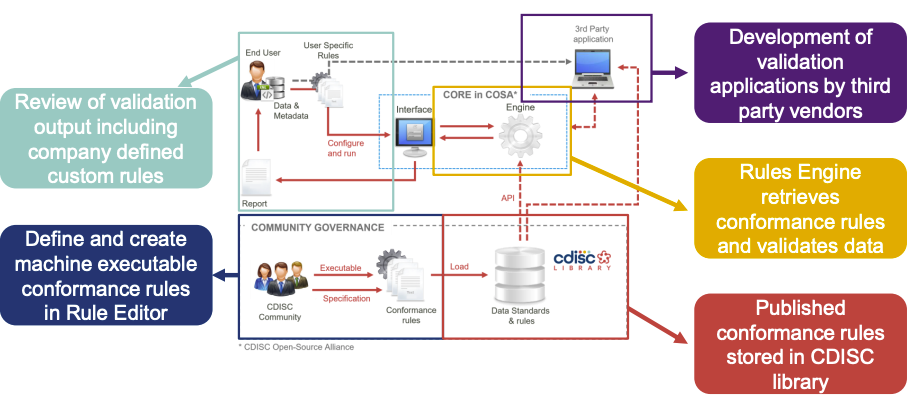

**Using the CORE Engine**

As seen throughout this notebook demonstration, the CDISC CORE Engine can be used to run Conformance Rules from the CDISC Library to validate the SDTM Trial Design Domains.  A validation report is created for any validation executed by the CORE Engine.

Once installed, the CORE rules local cache can be updated with the latest rules available in the CDISC Library.  In order to update the local CORE engine rules cache, the environmental parameter CDISC_API_KEY must exist.

Use the command `python core.py update-cache --apikey CDISC_API_KEY`

A full list of available core validate rule sets can be displayed using the command-line utility.

In [ ]:
# @title
# Display a list of rule sets available in CORE
change_working_dir(core_dir)
!./core list-rule-sets

Multiple CDISC standards and corresponding Conformance Rule sets are available.  We have used the SDTMIG, 3-4 Conformance Rules for our Trial Design Datasets as well as the Vital Signs dataset.

For additional commands, use the help page.

In [ ]:
# @title
!./core --help

Add additional command-line arguments to --help to see options and parameters available for a certain command.

`./core validate --help`

**Validate the USDM JSON file against the conformance rules defined in the CDISC Rules Engine**

This conformance report was also generated when we first uploaded the USDM JSON file.

This command is executed directly against the USDM JSON file in the Operational Data Store.

In [ ]:
# @title
# Validate the USDM JSON file against the USDM version 4 Conformance Rules
destination_path = os.path.join(DATA_DIR, 'usdm_validation_results')
!./core validate -s USDM -v 4-0 -o {destination_path} -dp {usdm_file_path}

### Working with the Conformance Report

Executing the CORE engine conformance rules will generate a report summarizing all executed rules and detailiing any failures for the study team to address.

In [ ]:
# @title
# View the Rules Report worksheet in the report produced by the CORE Engine
results_file = destination_path + '.xlsx'
df = pd.read_excel(results_file, sheet_name='Rules Report')
display(df)

In [ ]:
# @title
# View the Issue Summary worksheet in the report produced by the CORE Engine
df = pd.read_excel(results_file, sheet_name='Issue Summary')
display(df)

The Conformance Rules CORE-000810 and CORE-000427 are reporting issues.

In the next section, we will examine these rules in the Conformance Rules Editor to examine how these rules are defined.

### Conformance Rules Editor

The Conformance Rules Editor is used to define rules used to evaluate data sets and study resources against CDISC Standards and Business Rules.

Custom conformance rules can also be created using the Rule Editor.

Rules Editor: https://rule-editor.cdisc.org/

Search for the CORE rule CORE-000810 reported in the validation of the USDM JSON v4.


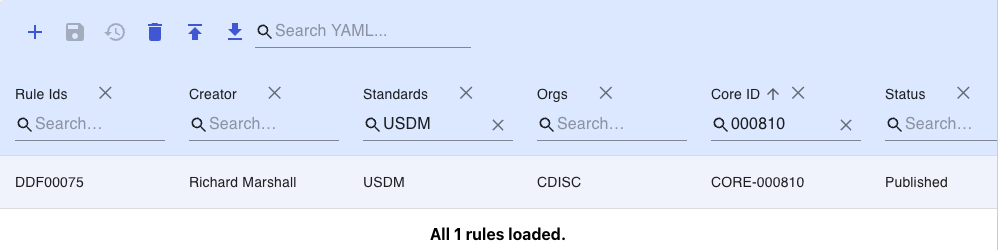

The text editor in the right-hand pane on the Rule Editor shows the YAML text used to define the Conformance Rule.

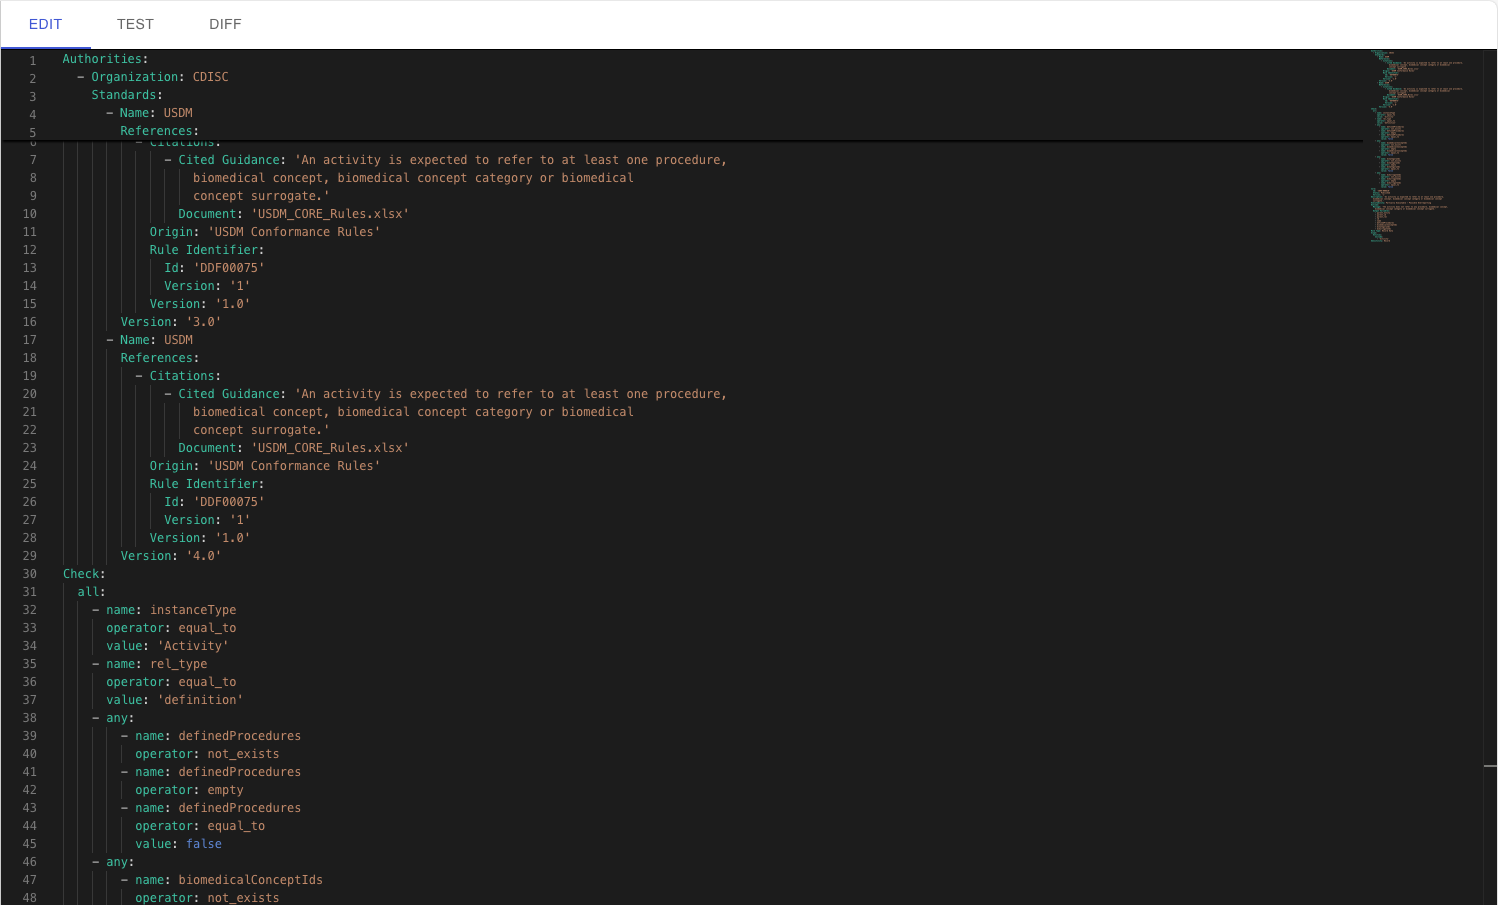

The `Description` and `Message` show the text reported in the CORE report.

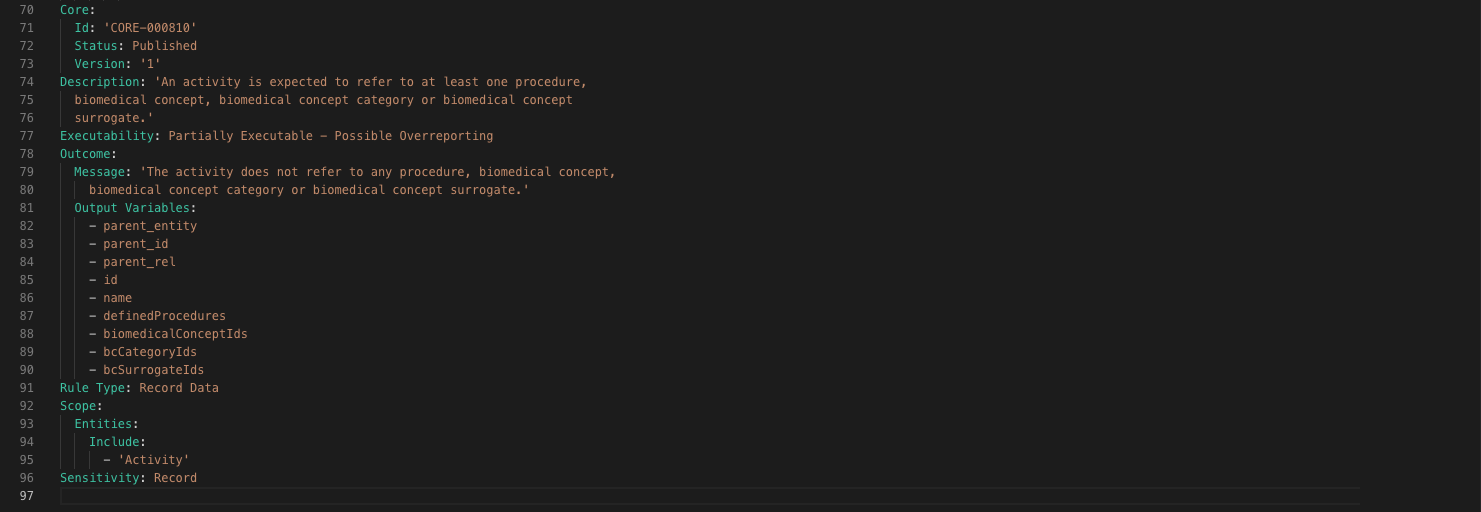

A full lising of rules defined for a standard can be accessed using filtering.

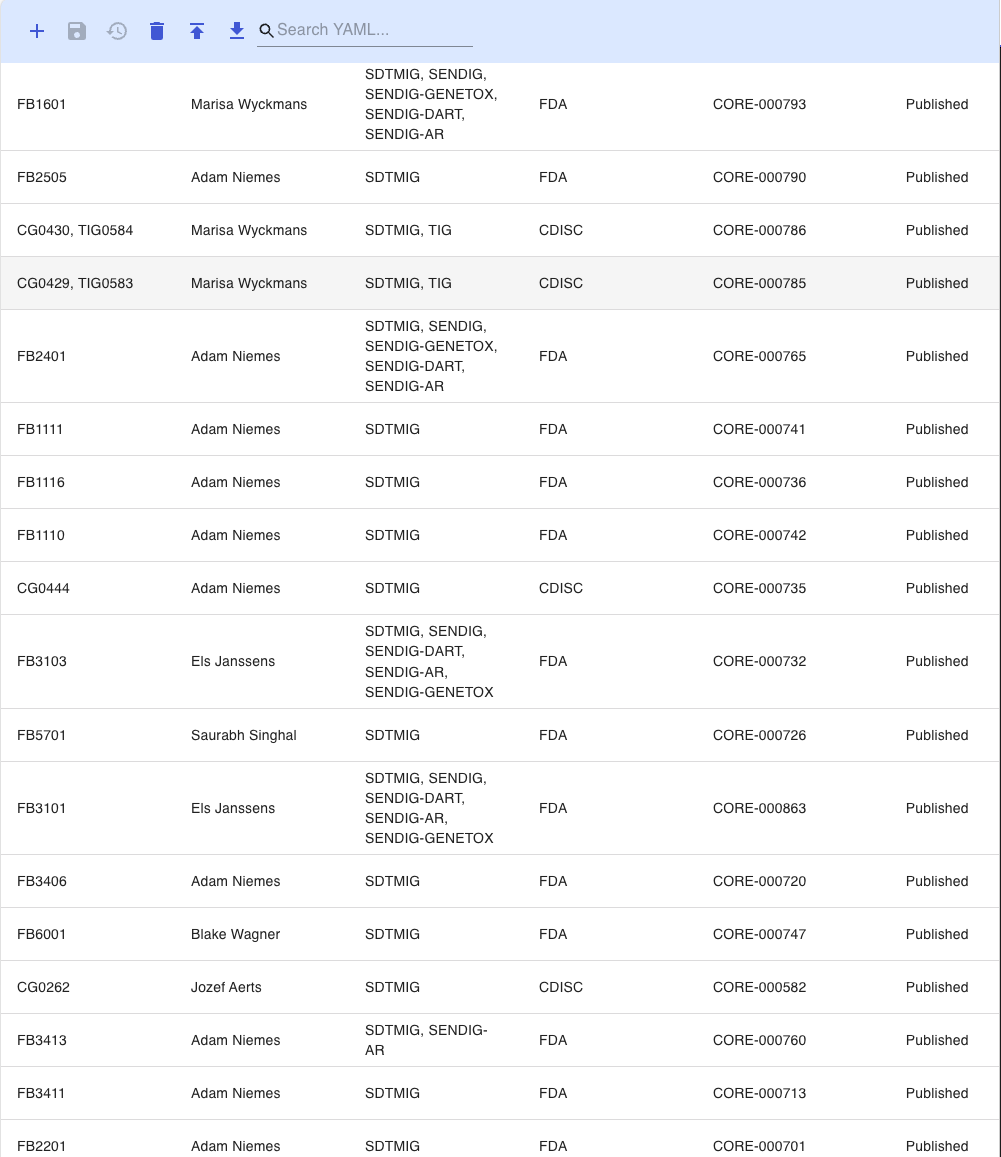

Additonally, a report for the filtered rules can be exported. View a summary of the SDTMIG Conformance Rules executed against the VS.xpt file produced using the sdtm.oak R library.

In [ ]:
# @title
# Display rules run against VS XPT file
url = "https://github.com/cdisc-org/cdisc-360i-notebooks/raw/main/SDTM_CORE_Rules.csv"
rules_file = os.path.basename(urllib.parse.urlsplit(url).path)
change_working_dir(CONTENT_DIR)
!wget {url}
UTIL_DIRS.append(rules_file)
core_report = os.path.join(CONTENT_DIR, rules_file)
df = pd.read_csv(core_report)
df = df[df['Core-ID'].isin(['CORE-000019', 'CORE-000182', 'CORE-000581', 'CORE-000594', 'CORE-000598', 'CORE-000739'])]
df = df[['Core-ID', 'CDISC Rule ID', 'Description', 'Standard Name', 'Standard Version', 'Executability']]
display(df)

Summary information is presented for the subset of the SDTMIG Conformance Rules executed against the VS domain XPT file generated using the {sdtm.oak} library.



---



## Summary

The 360i initiative has led to the creation of many open-source projects contributing to automating the study processes of Digital Protocol to SDTM submission.

The CDISC Pilot Study is defined in an XLSX notebook and used to create the USDM JSON study design through the Study Definitions Workbench. This USDM becomes an input for all downstream processes.

From the USDM, CRFs and annotated CRFs are created in ODM, JSON and HTML format for use as study assets and import into EDC systems.

The USDM is used to create SDTM Trial Design Domains, the Define-XML and empty SDTM domain shell data sets.

Raw clinical data is used in conjunction with the \{sdtm.oak} R library to generate R scripts used to create SDTM domains.

Throughout the noteboook, the CDISC CORE Rules engine is used to confirm standards conformance using the rules defined in the CDISC Library.

All conformant assets are stored in the Object Store to ensure backup, accountability and traceability in a single repository.  All tabular data used and created throughout the notebook are stored in the Relational Database.



---



## Cleanup

Use the cleanup cell below to remove all assets created during execution of this notebook.

In [ ]:
# @title
# Cleanup the working directory
change_working_dir(CONTENT_DIR)
print("INFO: Removing utility directories...")
for dir in UTIL_DIRS:
  if os.path.exists(dir):
    if os.path.isfile(dir):
      print("INFO: Removing {}...".format(dir))
      os.remove(dir)
    else:
      print("INFO: Removing {}...".format(dir))
      shutil.rmtree(dir)

**Uncomment the next code cell to remove the *study* directory entirely**

In [ ]:
# @title
# Uncomment to remove the study directory
#shutil.rmtree(CONTENT_DIR)

**Restart the session**

In [ ]:
exit(0)